# What the campaign found

**Eleven language models. Six feedback conditions. 30 runs each. 19,222 trained agents.**

One section per idea: a figure, then what it shows.

*Status: rung 1 of 7. Campaign runs to 27 August.*

## 1. The question

> **Show a language model the *shape of the losses* instead of one performance number.
> Does it write different reward code, and does the trained agent end up safer?**

Everything downstream is frozen. Same learner, data, splits, budget. **Only the feedback block
changes.**

One detail matters more than any other: **candidate selection is tail-blind** (fitness is validation
Deflated Sharpe, no tail term). So a better tail cannot come from selection. **It can only come from
the code the model wrote.**

## 2. Vocabulary

**The six conditions**

| arm | what the model sees | rules out |
|---|---|---|
| **`distributional`** | six left-tail statistics | *the treatment* |
| **`scalar`** | one performance number | *the comparison* |
| `scalar_cvar5` | one number + **one** tail number | "any risk number would do" |
| `placebo` | one number + **same-length filler** | "more text helps" |
| `placebo_shuffled` | the six values **scrambled** | "structure, not content" |

**The questions**

| | |
|---|---|
| **H1** | Does the model beat 11 human-written objectives from the literature? |
| **H2-RA** | **R**isk-**A**djusted. Does tail feedback raise **Sharpe**? |
| **H2-Tail** | Does tail feedback give a **less severe left tail** (CVaR-5%)? |
| **H3** | Does iterating 30 candidates beat one shot? |
| **H4** | Does the model beat 4 optimisers at the same budget? |
| **SQ1 / SQ2 / SQ3** | Does the signal change the code / reach the outcome / is it genuine? |

**The measures**

| | |
|---|---|
| **Sharpe** | return ÷ volatility. Higher better. |
| **CVaR-5%** | average loss on the worst 5% of days. Closer to zero better. |
| **turnover** | share of portfolio traded per day. Expensive. |
| **gross vs net** | before and after trading costs. |

## One rule that decides the headline

**`distributional` had to beat all three of `scalar`, `placebo` and `scalar_cvar5`. Not one. All
three.** That rule was fixed before any data existed.

This is called an **intersection-union test (IUT)**, and the score is the **worst** of the three
comparisons, not the best.

**Why "all three" is the safeguard.** Normally, running three tests gives you three chances to get
lucky, so you must penalise the result to compensate. **Here it works the opposite way.** Requiring
every test to pass means a fluke would have to strike three times, in the same direction, on three
different comparisons. That is far harder than passing one.

> **So no extra penalty is needed. Requiring all three to agree IS the penalty.** That is what
> "the conjunction is the correction" means (Berger, 1982).

**And each comparison kills a specific objection:**

- beating **`scalar`** shows there is an effect at all
- beating **`placebo`** kills "it was just a longer prompt"
- beating **`scalar_cvar5`** kills "any risk number would have done it"

In [1]:
import sys, pathlib
import numpy as np, pandas as pd, matplotlib.pyplot as plt

HERE = pathlib.Path.cwd()
REPO = next(p for p in [HERE, *HERE.parents] if (p / "src" / "viz" / "style.py").exists())
for p in (str(REPO), str(REPO / "notebooks")):
    if p not in sys.path: sys.path.insert(0, p)
import prelim_loader as PL
from src.viz.style import OKABE_ITO, savefig

plt.rcParams.update({"figure.dpi": 110, "savefig.dpi": 300, "font.size": 12,
                     "axes.titlesize": 14, "axes.labelsize": 12,
                     "axes.spines.top": False, "axes.spines.right": False,
                     "figure.constrained_layout.use": True, "legend.frameon": False})
FIG = REPO / "outputs" / "figures_presentation"; FIG.mkdir(parents=True, exist_ok=True)
rows, series = PL.load(REPO / "outputs" / "campaign_cluster_run4", REPO / "outputs" / "notebook_cache", verbose=False)
D = pd.DataFrame(rows); D["floor"] = D["seed"] < 30
BLUE, RED, GREY, GREEN, ORANGE = (OKABE_ITO["blue"], OKABE_ITO["vermillion"], OKABE_ITO["grey"],
                                  OKABE_ITO["green"], OKABE_ITO["orange"])
CONF = "opus_5"                       # the registered confirmatory line, one row among eleven

def nm(l): return "opus_5" if l == "test" else l.replace("test_leg_", "")
LINES = ["test"] + sorted(l for l in D.line.unique() if l.startswith("test_leg_"))
D["model"] = D.line.map(nm)
MODELS = [nm(l) for l in LINES]     # the 11 full-loop lines; excludes the single-arm H3 unit

def cell(l, a, m="sharpe"):
    q = D[(D.line == l) & (D.arm == a) & D.floor]
    return q.set_index("seed")[m].dropna().sort_index()
def paired(l, a, b, m="sharpe"):
    x, y = cell(l, a, m), cell(l, b, m)
    c = x.index.intersection(y.index); return (x.loc[c] - y.loc[c]).to_numpy(float)
def boot(x, reps=4000, al=0.10, seed=0):
    x = np.asarray(x, float); x = x[np.isfinite(x)]
    if x.size < 2: return (float("nan"),) * 3
    r = np.random.default_rng(seed); m = x[r.integers(0, x.size, (reps, x.size))].mean(1)
    lo, hi = np.quantile(m, [al/2, 1-al/2]); return float(x.mean()), float(lo), float(hi)
def p_one(x, reps=20000, seed=0):
    x = np.asarray(x, float); x = x[np.isfinite(x)]
    o = x.mean(); r = np.random.default_rng(seed)
    return float((1 + int(((r.choice(np.array([-1.,1.]), (reps, x.size)) * x).mean(1) >= o).sum())) / (reps+1))

print("%d trained agents | %d models | %d arms" % (len(D), len(LINES), D.arm.nunique()))
print("confirmatory line (registered in advance): %s" % CONF)

19222 trained agents | 11 models | 20 arms
confirmatory line (registered in advance): opus_5


## 3. What the model actually saw, and what it wrote

Before any results, here is the real thing. **These are the archived prompts and the archived code**,
read from disk, not reconstructed.

Each arm's prompt is identical except for one block. That block is the entire experiment.

In [2]:
import textwrap
SEARCH = REPO / "outputs" / "campaign_cluster_run4" / "search"

def feedback_block(arm):
    # the archived text the model was shown before writing its next attempt
    cands = sorted(SEARCH.glob("%s/*-g1-*/prompt.txt" % arm)) or sorted(SEARCH.glob("%s/*/prompt.txt" % arm))
    if not cands: return None, None
    t = cands[0].read_text(encoding="utf-8", errors="replace")
    start = t.find("Feedback from the previous candidate:")
    end = t.find("[Exploration directive")
    if start < 0: return cands[0].parent.name, t[:600]
    return cands[0].parent.name, t[start + len("Feedback from the previous candidate:"):(end if end > 0 else None)].strip()

ORDER = ["scalar", "scalar_cvar5", "placebo", "placebo_shuffled", "distributional"]
for arm in ORDER:
    who, blk = feedback_block(arm)
    print("=" * 86)
    print("ARM: %-18s   (archived candidate: %s)" % (arm, who))
    print("=" * 86)
    print(textwrap.indent(blk or "(none archived)", "    "))
    print()

ARM: scalar               (archived candidate: scalar-g1-c2)
    Your previous reward scored: 0.009580 (validation Deflated Sharpe).

ARM: scalar_cvar5         (archived candidate: scalar_cvar5-g1-c1)
    Your previous reward scored: 0.011554 (validation Deflated Sharpe).
      CVaR 5%: -0.0233

ARM: placebo              (archived candidate: placebo-g1-c0)
    Your previous reward scored: 0.010708 (validation Deflated Sharpe).
    Reference constants (inert; no diagnostic content):
      reference value 1: +0.0000
      reference value 2: +0.0000
      reference value 3: +0.0000
      reference value 4: +0.0000
      reference value 5: +0.0000
      reference value 6: +0.0000

ARM: placebo_shuffled     (archived candidate: placebo_shuffled-g1-c1)
    Your previous reward scored: 0.258919 (validation Deflated Sharpe).
    Realized-return tail diagnostics (training period):
      CVaR 5%: +0.0182
      CVaR 10%: -0.0092
      CVaR 25%: -0.0073
      CVaR 1%: -0.0147  (high-variance estim

### What to notice

- **`scalar`** gets **one line**: a single score. That is the normal way to run this kind of loop.
- **`distributional`** gets the same score **plus six numbers describing the losses**: how bad the
  worst 1%, 5%, 10% and 25% of days were, how often big losses happened, and how lopsided they were.
- **`scalar_cvar5`** gets the score plus **exactly one** of those six.
- **`placebo`** gets six extra lines that are all **`+0.0000`** and labelled "inert; no diagnostic
  content". **Same length, zero information.**

### ★ Look closely at `placebo_shuffled`

Its `CVaR 5%` reads **positive**. A CVaR is an average *loss*, so a positive value is impossible for
a real one. And it reports a worse number at 10% than at 5%, which reverses the natural ordering.

> **Scrambling does not just remove the information. It produces numbers that are internally
> contradictory.** That is why this arm is the harshest control, and why it is often the worst
> performer: a model that trusts the block is actively misled.

In [3]:
def winner_code(line, arm):
    # the FROZEN winning reward function that every test run actually trained against
    q = D[(D.line == line) & (D.arm == arm)]
    if q.empty: return None
    p = next((REPO / "outputs" / "campaign_cluster_run4" / line / arm).glob("*/record.json"), None)
    if p is None: return None
    import json
    return json.loads(p.read_text(encoding="utf-8")).get("reward_source") or ""

for arm in ORDER:
    src = winner_code("test", arm)
    if not src: continue
    body = [l for l in src.split("\n") if l.strip()]
    print("=" * 86)
    print("WINNING REWARD FUNCTION -- arm: %s   (%d lines, %d chars)" % (arm, len(body), len(src)))
    print("=" * 86)
    print("\n".join(src.split("\n")[:46]))
    if len(src.split("\n")) > 46: print("    ...  (%d more lines)" % (len(src.split("\n")) - 46))
    print()

WINNING REWARD FUNCTION -- arm: scalar   (108 lines, 4761 chars)
def reward(weights, returns, prev_weights, port_ret, info):
    import numpy as _np  # noqa: F401  (numpy is provided as np; alias kept harmless)

    eps = 1e-12
    w = np.asarray(weights, dtype=float).ravel()
    pw = np.asarray(prev_weights, dtype=float).ravel() if prev_weights is not None else w
    r = float(port_ret) if np.isfinite(port_ret) else 0.0
    r = float(np.clip(r, -0.5, 0.5))

    st = info.get("reward_state", None) if isinstance(info, dict) else None

    # ---------------- state init ----------------
    WIN = 45  # rolling window for robust location/scale
    if st is None:
        st = {
            "n": 0,
            "buf": [0.0] * 0,          # rolling window of portfolio returns
            "ew_mean": 0.0,            # fast EWMA mean
            "ew_dvar": 0.0004,         # EWMA downside variance (prior ~2% dd vol)
            "ew_var": 0.0004,          # EWMA total variance
            "logeq": 

### What to notice in the code

**These are real programs, not formulas.** Around a hundred lines each, carrying rolling windows,
exponentially weighted moments, drawdown tracking, clipping and their own persistent state between
steps. **No human wrote a line of this.**

Only the first 46 lines of each are shown. The counts printed above are the full length.

Read them side by side and ask one question: **does the code mention trading cost or turnover?**
That single feature turns out to predict the arm's result better than anything else, which is what
Section 8 shows.

## 4. What the reward functions actually DO

The code in section 3 is hard to read. **So we run it.**

Each frozen reward is warmed up on a realistic return path, then probed two ways:

1. **Feed it a day's return** from -4% to +4% and record the reward it hands back.
2. **Feed it a day of trading** from 0% to 100% turnover at zero return, and record the penalty.

This turns 100 lines of code into two curves.

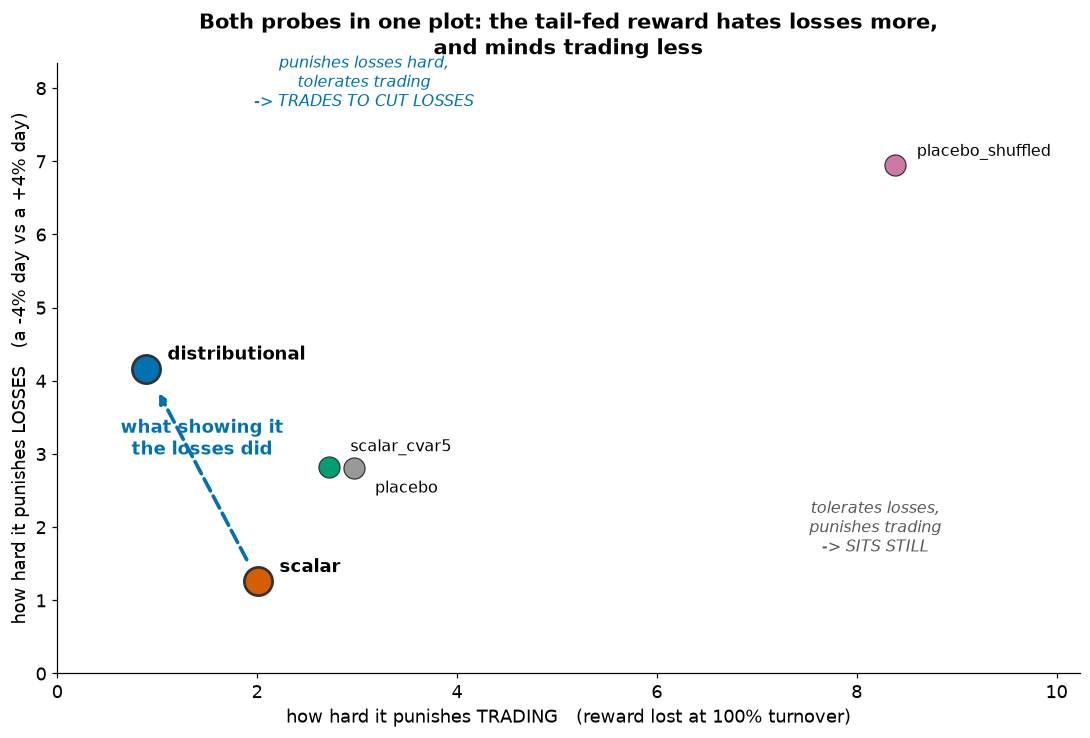

,reward at -4% day,reward at +4% day,punishes losses (ratio),punishes trading
arm,,,,
scalar,-2.761,2.191,1.260,2.010
scalar_cvar5,-5.806,2.053,2.827,2.719
placebo,-7.569,2.698,2.806,2.966
placebo_shuffled,-13.905,2.001,6.948,8.388
distributional,-5.285,1.269,4.164,0.889


In [4]:
import json
N_ASSET = 30
TESTROOT = REPO / "outputs" / "campaign_cluster_run4" / "test"

def load_reward(arm):
    # exec the archived source; contract is reward(...) -> (total, components, state)
    p = next((TESTROOT / arm).glob("*/record.json"), None)
    if p is None: return None
    src = json.loads(p.read_text(encoding="utf-8")).get("reward_source") or ""
    ns = {"np": np, "__builtins__": __builtins__}
    try:
        exec(src, ns); return ns.get("reward")
    except Exception:
        return None

def warm_state(f, seed, steps=250):
    # these rewards carry rolling state, so they must be warmed before probing
    rng = np.random.default_rng(seed)
    w = np.full(N_ASSET + 1, 1.0 / (N_ASSET + 1)); st = None
    for r in rng.normal(0.0004, 0.011, steps):
        _, _, st = f(w, None, w, float(r), {"reward_state": st})
    return st, w

def probe(arm, seeds=(0,1,2,3,4)):
    f = load_reward(arm)
    if f is None: return None
    xs = np.linspace(-0.04, 0.04, 33)
    fr = np.linspace(0.0, 1.0, 11)
    R, T = [], []
    for sd in seeds:
        st, w = warm_state(f, sd)
        cp = lambda: {"reward_state": (dict(st) if isinstance(st, dict) else st)}
        R.append([f(w, None, w, float(x), cp())[0] for x in xs])
        row = []
        for frac in fr:
            w2 = w.copy(); k = max(1, int(N_ASSET * frac / 2))
            w2[:k] += w[0] * frac * 2; w2[k:2*k] -= w[0] * frac * 2
            w2 = np.clip(w2, 0, None); w2 /= w2.sum()
            row.append(f(w2, None, w, 0.0, cp())[0])
        T.append(row)
    return xs, np.nanmedian(R, 0), fr, np.nanmedian(T, 0)

ARMS5 = ["scalar", "scalar_cvar5", "placebo", "placebo_shuffled", "distributional"]
AC = {"distributional": BLUE, "scalar": RED, "scalar_cvar5": GREEN,
      "placebo": GREY, "placebo_shuffled": OKABE_ITO["purple"]}

summary = []
for arm in ARMS5:
    pr = probe(arm)
    if pr is None: continue
    xs, ry, fr, ty = pr
    lo, hi = ry[0], ry[-1]
    summary.append({"arm": arm, "reward at -4% day": lo, "reward at +4% day": hi,
                    "punishes losses (ratio)": abs(lo) / abs(hi) if hi else np.nan,
                    "punishes trading": -(ty[-1] - ty[0])})
S12 = pd.DataFrame(summary).set_index("arm")

# ONE panel. The two sweeps reduce to two numbers per arm, so the honest combined
# exhibit is the plane they live in, not two curves side by side.
fig, ax = plt.subplots(figsize=(9.8, 6.6))
for arm, row in S12.iterrows():
    big = arm in ("distributional", "scalar")
    ax.scatter(row["punishes trading"], row["punishes losses (ratio)"],
               s=340 if big else 190, color=AC[arm], edgecolor="0.2",
               linewidth=1.8 if big else 0.8, zorder=4)
    # scalar_cvar5 and placebo land almost on top of each other, so their labels
    # are pushed in opposite directions rather than overprinting
    OFF = {"scalar_cvar5": (14, 10), "placebo": (14, -16)}
    ax.annotate(arm, (row["punishes trading"], row["punishes losses (ratio)"]),
                fontsize=11.5 if big else 10.5, fontweight="bold" if big else "normal",
                xytext=OFF.get(arm, (14, 6)), textcoords="offset points")
d, sc = S12.loc["distributional"], S12.loc["scalar"]
ax.annotate("", xy=(d["punishes trading"], d["punishes losses (ratio)"]),
            xytext=(sc["punishes trading"], sc["punishes losses (ratio)"]),
            arrowprops=dict(arrowstyle="-|>", color=BLUE, lw=2.4, ls="--",
                            shrinkA=16, shrinkB=18), zorder=3)
ax.text(0.5 * (d["punishes trading"] + sc["punishes trading"]),
        0.5 * (d["punishes losses (ratio)"] + sc["punishes losses (ratio)"]) + 0.28,
        "what showing it" + chr(10) + "the losses did", color=BLUE, fontsize=11.5,
        fontweight="bold", ha="center")
ax.set_xlabel("how hard it punishes TRADING   (reward lost at 100% turnover)")
ax.set_ylabel("how hard it punishes LOSSES   (a -4% day vs a +4% day)")
ax.set_title("Both probes in one plot: the tail-fed reward hates losses more," + chr(10) + "and minds trading less",
             fontweight="bold")
ax.set_xlim(0, max(S12["punishes trading"]) * 1.22)
ax.set_ylim(0, max(S12["punishes losses (ratio)"]) * 1.20)
ax.text(0.30, 0.93, "punishes losses hard," + chr(10) + "tolerates trading" + chr(10) + "-> TRADES TO CUT LOSSES",
        transform=ax.transAxes, fontsize=10.5, color=BLUE, ha="center", style="italic")
ax.text(0.80, 0.20, "tolerates losses," + chr(10) + "punishes trading" + chr(10) + "-> SITS STILL",
        transform=ax.transAxes, fontsize=10.5, color="0.35", ha="center", style="italic")
savefig(fig, FIG / "P12_reward_shapes.png"); plt.show()
display(S12.round(3))

### How to read it

Two probes, two numbers per arm, one plot.

- **Up the chart** = punishes losses harder. **Right** = punishes trading harder.
- The dashed arrow is **the entire experiment**: it runs from `scalar` to `distributional`, the only
  two arms that differ solely in what the model was shown.

### ★ Finding 1: the tail-fed reward is far more loss-averse

`scalar` punishes a 4% loss only **1.3x** as hard as it rewards a 4% gain. `distributional`
punishes it **4.2x** as hard.

> **This is the first code-level evidence for the study's central claim.** The model was shown the
> shape of the losses and wrote a reward that cares about losses roughly three times more. **We are
> no longer inferring that the code changed. We can see it.**

### ★ Finding 2: and it minds trading the least

`distributional` sits furthest **left**: the smallest trading penalty of the five, 0.9 against 2.0
for `scalar`.

**The arrow points up and to the left, and that direction is the whole mechanism:**

> **The tail-fed reward tells the agent that losses are very bad and trading is cheap.** A rational
> agent given those instructions **trades hard to cut losses**. That is exactly what was measured:
> turnover rose from 0.028 to 0.057, and the extra fees cost more than the avoided losses saved.

**The reward did what it was designed to do. Its designer underpriced the fee.**

`placebo_shuffled` sits in the far corner, extreme on both axes, which fits section 3: it was fed
internally contradictory numbers and over-reacted to them.

⚠ **Caveat.** One frozen winner per arm on the confirmatory line, probed after a synthetic warm-up,
median over five warm-up paths. The shape is robust to the warm-up, but this is one reward per arm
rather than a distribution over candidates.

## 5. Every model, both halves of H2

Each row is one model. **Left: did the tail get safer? Right: did Sharpe rise?**

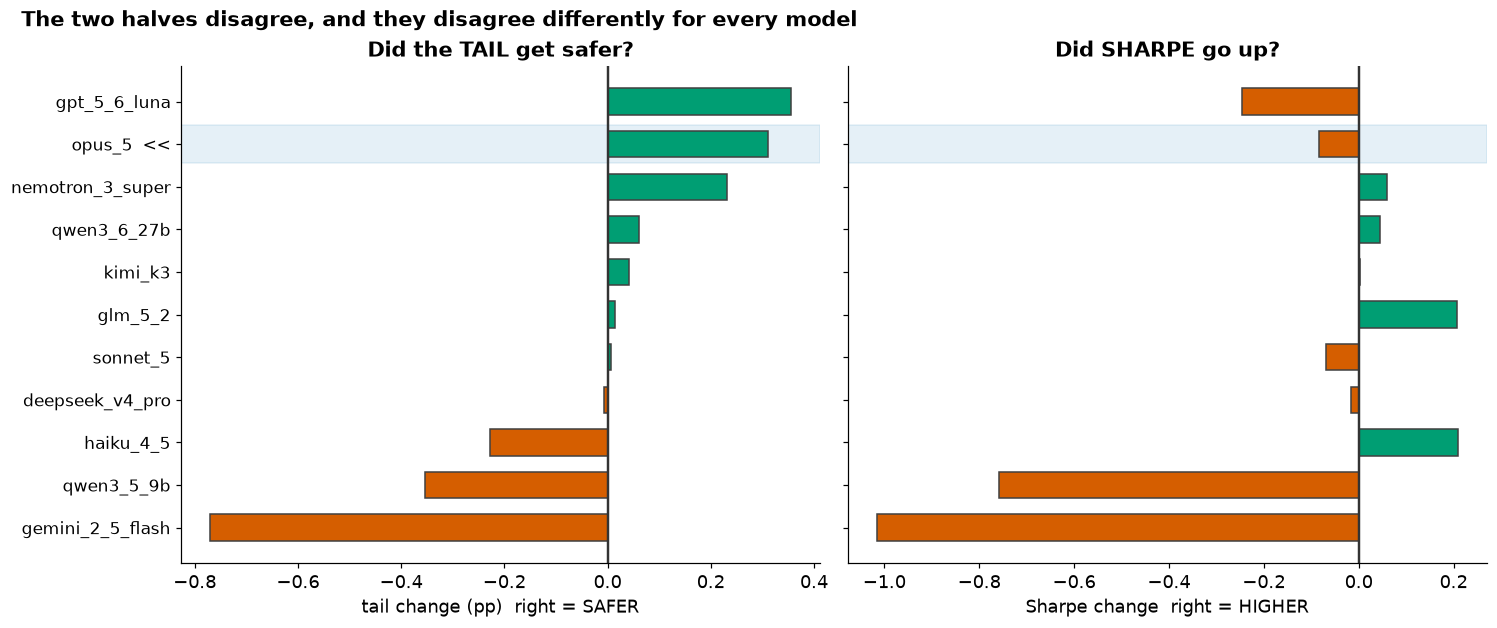

,tail effect,sharpe effect,H2-Tail (all 3 legs)
model,,,
gemini_2_5_flash,-0.7697,-1.0150,False
qwen3_5_9b,-0.3548,-0.7587,False
haiku_4_5,-0.2280,0.2088,False
deepseek_v4_pro,-0.0077,-0.0154,False
sonnet_5,0.0062,-0.0685,False
glm_5_2,0.0142,0.2074,False
kimi_k3,0.0421,0.0028,False
qwen3_6_27b,0.0609,0.0458,False
nemotron_3_super,0.2322,0.0601,False


In [5]:
COMPS = ("scalar", "placebo", "scalar_cvar5")
R = []
for l in LINES:
    ps = [p_one(paired(l, "distributional", c, "oos_cvar_05")) for c in COMPS]
    R.append({"model": nm(l),
              "tail effect": paired(l, "distributional", "scalar", "oos_cvar_05").mean() * 100,
              "sharpe effect": paired(l, "distributional", "scalar", "sharpe").mean(),
              "H2-Tail (all 3 legs)": max(ps) < 0.05})
R = pd.DataFrame(R).sort_values("tail effect")

fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.6), sharey=True)
y = np.arange(len(R))
for ax, col, lab, good_right in ((axes[0], "tail effect", "tail change (pp)  right = SAFER", True),
                                 (axes[1], "sharpe effect", "Sharpe change  right = HIGHER", True)):
    cols = [GREEN if v > 0 else RED for v in R[col]]
    ax.barh(y, R[col], color=cols, edgecolor="0.25", height=0.62)
    ax.axvline(0, color="0.2", lw=1.6)
    ax.set_xlabel(lab)
for i, m in enumerate(R.model):
    if m == CONF:
        for ax in axes:
            ax.axhspan(i-0.45, i+0.45, color=BLUE, alpha=0.10, zorder=0)
axes[0].set_yticks(y)
axes[0].set_yticklabels([("%s  <<" % m) if m == CONF else m for m in R.model], fontsize=11)
axes[0].set_title("Did the TAIL get safer?", fontweight="bold")
axes[1].set_title("Did SHARPE go up?", fontweight="bold")
fig.suptitle("The two halves disagree, and they disagree differently for every model",
             x=0.01, ha="left", fontsize=13.5, fontweight="bold")
savefig(fig, FIG / "P1_two_halves.png"); plt.show()
display(R.set_index("model").round(4))

**Three things to see.**

- **The two columns are not the same ranking.** A model can get a safer tail and a lower Sharpe, or
  the reverse. That is why the study registered two separate tests.
- **The signs are mixed.** Tail feedback helps some models and harms others. **There is no single
  effect to report.**
- **`opus_5` (highlighted) is the registered confirmatory line**, chosen before any data. It is the
  only model that passes the full three-comparator test, and it is one row among eleven.

## 6. All the numbers

Every model, every arm, every measure. Sorted by Sharpe within each model.

In [6]:
COLS = {"sharpe":"Sharpe", "ann_return":"return/yr", "ann_vol":"volatility",
        "oos_cvar_05":"CVaR-5%", "max_drawdown":"max DD", "sortino":"Sortino",
        "calmar":"Calmar", "turnover_mean":"turnover", "sharpe_gross":"Sharpe gross",
        "hit_rate":"hit rate", "skew":"skew", "kurtosis":"kurtosis",
        "exp_eff_n":"holdings", "safe_default_rate":"crash rate"}
FEED = ["distributional","scalar","scalar_cvar5","placebo","placebo_shuffled"]

def table(line, arms=None):
    q = D[(D.line == line) & D.floor]
    if arms is not None: q = q[q.arm.isin(arms)]
    t = q.groupby("arm").agg(runs=("seed","count"), **{v:(k,"mean") for k,v in COLS.items()})
    return t.sort_values("Sharpe", ascending=False).round(4)

print("=" * 60); print("THE CONFIRMATORY LINE: opus_5, ALL 20 ARMS"); print("=" * 60)
t = table("test"); t.index = [i.replace("baseline_","HUMAN: ") for i in t.index]
display(t)

THE CONFIRMATORY LINE: opus_5, ALL 20 ARMS


,runs,Sharpe,return/yr,volatility,CVaR-5%,max DD,Sortino,Calmar,turnover,Sharpe gross,hit rate,skew,kurtosis,holdings,crash rate
HUMAN: return_minus_turnover,30,1.1609,0.1574,0.1352,-0.0187,-0.1903,1.1677,0.8439,0.0077,1.1751,0.5396,-0.0594,7.3598,13.5375,0.0
scalar_cvar5,30,1.1558,0.1580,0.1355,-0.0187,-0.1851,1.1642,0.8700,0.0214,1.1951,0.5402,-0.0248,7.5045,11.0932,0.0
placebo,30,1.1454,0.1522,0.1327,-0.0183,-0.1893,1.1485,0.8304,0.0129,1.1700,0.5405,-0.0715,7.2116,11.9438,0.0
scalar,30,1.1354,0.1614,0.1414,-0.0195,-0.2013,1.1408,0.8205,0.0284,1.1860,0.5397,-0.0386,7.3743,10.8581,0.0
placebo_shuffled,30,1.1047,0.1542,0.1390,-0.0192,-0.2040,1.1129,0.7746,0.0328,1.1640,0.5370,-0.0199,7.3483,11.5398,0.0
distributional,30,1.0527,0.1257,0.1187,-0.0164,-0.1756,1.0481,0.7313,0.0570,1.1733,0.5391,-0.1149,6.6880,11.4754,0.0
bayes_opt,30,1.0503,0.1248,0.1185,-0.0163,-0.1725,1.0538,0.7484,0.0333,1.1208,0.5358,-0.0758,6.3252,10.7987,0.0
random_search,30,0.9203,0.1044,0.1128,-0.0155,-0.1658,0.9278,0.6615,0.0739,1.0859,0.5316,0.0051,6.7826,8.3863,0.0
tpe,30,0.8876,0.1181,0.1329,-0.0184,-0.2089,0.8864,0.6048,0.1228,1.1176,0.5328,-0.0763,6.8550,9.1245,0.0
cma_es,30,0.4391,0.0476,0.1074,-0.0149,-0.1885,0.4436,0.2978,0.2613,1.0539,0.5177,0.1365,7.9865,7.2319,0.0


In [7]:
for l in LINES[1:]:
    print("\n" + "=" * 60); print(nm(l).upper()); print("=" * 60)
    display(table(l, FEED))


DEEPSEEK_V4_PRO


,runs,Sharpe,return/yr,volatility,CVaR-5%,max DD,Sortino,Calmar,turnover,Sharpe gross,hit rate,skew,kurtosis,holdings,crash rate
arm,,,,,,,,,,,,,,,
scalar,30,1.1781,0.1656,0.1402,-0.0194,-0.1968,1.1867,0.8569,0.0076,1.1917,0.5396,-0.0486,7.3952,12.6845,0.0
scalar_cvar5,30,1.1701,0.1638,0.1398,-0.0194,-0.2003,1.1795,0.8334,0.0141,1.1954,0.5391,-0.0395,7.3706,13.6542,0.0
distributional,30,1.1627,0.1651,0.1414,-0.0195,-0.1987,1.1695,0.8488,0.0103,1.1812,0.5397,-0.0586,7.2296,11.0911,0.0
placebo,30,1.1555,0.1627,0.1406,-0.0195,-0.1954,1.1641,0.8588,0.0073,1.1687,0.5392,-0.0433,7.5220,13.5262,0.0
placebo_shuffled,30,1.1181,0.1575,0.1405,-0.0195,-0.1976,1.1229,0.8275,0.0211,1.1556,0.5387,-0.0640,7.3148,11.2027,0.0



GEMINI_2_5_FLASH


,runs,Sharpe,return/yr,volatility,CVaR-5%,max DD,Sortino,Calmar,turnover,Sharpe gross,hit rate,skew,kurtosis,holdings,crash rate
arm,,,,,,,,,,,,,,,
scalar_cvar5,30,1.0337,0.1272,0.1224,-0.0168,-0.1814,1.0378,0.7145,0.0318,1.0990,0.5358,-0.0514,6.6337,10.2052,0.0
scalar,30,0.7988,0.1224,0.1513,-0.0212,-0.2549,0.8008,0.4927,0.2161,1.1615,0.5285,-0.0505,7.1786,9.8382,0.0
placebo,30,0.7960,0.1207,0.1510,-0.0210,-0.2335,0.8088,0.5384,0.1858,1.1086,0.5268,0.1896,10.4609,9.5738,0.0
placebo_shuffled,30,0.4949,0.0748,0.1477,-0.0209,-0.2750,0.4959,0.2882,0.3659,1.1218,0.5183,-0.0331,7.2731,9.9399,0.0
distributional,30,-0.2162,-0.0424,0.1996,-0.0289,-0.5570,-0.2157,-0.0612,0.8891,0.9096,0.4750,0.4031,14.1860,3.5746,0.0



GLM_5_2


...

,runs,Sharpe,return/yr,volatility,CVaR-5%,max DD,Sortino,Calmar,turnover,Sharpe gross,hit rate,skew,kurtosis,holdings,crash rate
arm,,,,,,,,,,,,,,,
scalar_cvar5,30,1.2131,0.1617,0.1334,-0.0188,-0.1984,1.2193,0.8206,0.0364,1.2814,0.5390,-0.1026,8.1305,29.9768,0.0000
placebo,30,1.2087,0.1668,0.1378,-0.0192,-0.1944,1.2158,0.8677,0.0059,1.2194,0.5407,-0.0613,7.7289,17.6669,0.0000
scalar,30,0.5006,0.0696,0.1386,-0.0198,-0.2630,0.5002,0.2864,0.3960,1.2214,0.5174,-0.0680,7.9760,15.3864,0.0000
placebo_shuffled,30,0.0579,0.0095,0.1519,-0.0218,-0.3725,0.0590,0.0348,0.6320,1.1120,0.5041,-0.0165,7.1108,8.3507,0.0908
distributional,30,-0.2582,-0.0421,0.1613,-0.0233,-0.4902,-0.2572,-0.0775,0.8296,1.0405,0.4912,0.1740,9.6297,6.1827,0.0785



QWEN3_6_27B


,runs,Sharpe,return/yr,volatility,CVaR-5%,max DD,Sortino,Calmar,turnover,Sharpe gross,hit rate,skew,kurtosis,holdings,crash rate
arm,,,,,,,,,,,,,,,
placebo,30,1.1681,0.1594,0.1361,-0.0190,-0.1950,1.1747,0.8255,0.0209,1.2069,0.5388,-0.0725,7.6655,16.8562,0.0
distributional,30,1.1161,0.1580,0.1415,-0.0196,-0.2018,1.1235,0.8130,0.0328,1.1712,0.5371,-0.0648,7.4415,12.3949,0.0
scalar_cvar5,30,1.0921,0.1374,0.1247,-0.0171,-0.1776,1.0986,0.7822,0.0171,1.1268,0.5365,-0.0598,6.6357,10.8924,0.0
scalar,30,1.0703,0.1562,0.1457,-0.0202,-0.2152,1.0766,0.7467,0.0494,1.1596,0.5369,-0.0287,7.1653,9.9859,0.0
placebo_shuffled,30,1.0253,0.1455,0.1415,-0.0196,-0.2131,1.0290,0.7106,0.1018,1.2063,0.5355,-0.0512,7.5469,10.9994,0.0



SONNET_5


,runs,Sharpe,return/yr,volatility,CVaR-5%,max DD,Sortino,Calmar,turnover,Sharpe gross,hit rate,skew,kurtosis,holdings,crash rate
arm,,,,,,,,,,,,,,,
scalar,30,1.1671,0.1628,0.1389,-0.0193,-0.1919,1.1745,0.8604,0.0109,1.1868,0.5386,-0.0653,7.4391,13.0719,0.0
distributional,30,1.0986,0.1530,0.1389,-0.0193,-0.2036,1.1067,0.7639,0.0475,1.1861,0.5359,-0.0512,7.2910,11.3188,0.0
placebo,30,1.0981,0.1546,0.1405,-0.0195,-0.1941,1.1058,0.8162,0.0177,1.1299,0.5369,-0.0420,7.6170,11.4282,0.0
scalar_cvar5,30,0.9142,0.1019,0.1105,-0.0151,-0.1613,0.9213,0.6442,0.0394,1.0051,0.5322,0.0326,6.6460,9.0245,0.0
placebo_shuffled,30,0.3575,0.0527,0.1533,-0.0220,-0.3324,0.3593,0.2648,0.4501,1.0897,0.5118,-0.0229,8.0400,11.1751,0.0


In [8]:
print("ONE TABLE: the treatment arm on every model, side by side")
big = []
for l in LINES:
    for a in FEED:
        q = D[(D.line == l) & (D.arm == a) & D.floor]
        if q.empty: continue
        r = {"model": nm(l), "arm": a, "runs": len(q)}
        r.update({v: round(q[k].mean(), 4) for k, v in COLS.items()})
        big.append(r)
BIG = pd.DataFrame(big).set_index(["model","arm"])
display(BIG)
BIG.to_csv(REPO / "outputs" / "all_results_seed30.csv")
print("saved to outputs/all_results_seed30.csv")

ONE TABLE: the treatment arm on every model, side by side


runs  Sharpe  return/yr  volatility  \
model            arm                                                     
opus_5           distributional      30  1.0527     0.1257      0.1187   
                 scalar              30  1.1354     0.1614      0.1414   
                 scalar_cvar5        30  1.1558     0.1580      0.1355   
                 placebo             30  1.1454     0.1522      0.1327   
                 placebo_shuffled    30  1.1047     0.1542      0.1390   
deepseek_v4_pro  distributional      30  1.1627     0.1651      0.1414   
                 scalar              30  1.1781     0.1656      0.1402   
                 scalar_cvar5        30  1.1701     0.1638      0.1398   
                 placebo             30  1.1555     0.1627      0.1406   
                 placebo_shuffled    30  1.1181     0.1575      0.1405   
gemini_2_5_flash distributional      30 -0.2162    -0.0424      0.1996   
                 scalar              30  0.7988     0.1224      0.1513   
                 scalar_cvar5        30  1.0337     0.1272      0.1224   
                 placebo             30  0.7960     0.1207      0.1510   
                 placebo_shuffled    30  0.4949     0.0748      0.1477   
glm_5_2          distributional      30  0.6516     0.1001      0.1503   
                 scalar              30  0.4442     0.0674      0.1495   
                 scalar_cvar5        30  1.2135     0.1706      0.1404   
                 placebo             30  1.1534     0.1629      0.1410   
                 placebo_shuffled    30  0.7864     0.1135      0.1448   
gpt_5_6_luna     distributional      30  0.8818     0.1187      0.1355   
                 scalar              30  1.1286     0.1812      0.1605   
                 scalar_cvar5        30  1.1330     0.1465      0.1292   
                 placebo             30  1.1255     0.1622      0.1435   
                 placebo_shuffled    30  1.2014     0.1586      0.1316   
haiku_4_5        distributional      30  1.1716     0.1644      0.1404   
                 scalar              30  0.9628     0.1214      0.1252   
                 scalar_cvar5        30  1.0638     0.1475      0.1384   
                 placebo             30  1.2072     0.1671      0.1381   
                 placebo_shuffled    30  1.0781     0.1429      0.1322   
kimi_k3          distributional      30  1.1586     0.1596      0.1371   
                 scalar              30  1.1558     0.1623      0.1401   
                 scalar_cvar5        30  0.9543     0.1383      0.1444   
                 placebo             30  1.1644     0.1585      0.1356   
                 placebo_shuffled    30  1.0195     0.1403      0.1376   
nemotron_3_super distributional      30  0.6434     0.0872      0.1355   
                 scalar              30  0.5832     0.0903      0.1521   
                 scalar_cvar5        30  1.1191     0.1581      0.1410   
                 placebo             30  1.1712     0.1619      0.1377   
                 placebo_shuffled    30  0.7130     0.1074      0.1492   
qwen3_5_9b       distributional      30 -0.2582    -0.0421      0.1613   
                 scalar              30  0.5006     0.0696      0.1386   
                 scalar_cvar5        30  1.2131     0.1617      0.1334   
                 placebo             30  1.2087     0.1668      0.1378   
                 placebo_shuffled    30  0.0579     0.0095      0.1519   
qwen3_6_27b      distributional      30  1.1161     0.1580      0.1415   
                 scalar              30  1.0703     0.1562      0.1457   
                 scalar_cvar5        30  1.0921     0.1374      0.1247   
                 placebo             30  1.1681     0.1594      0.1361   
                 placebo_shuffled    30  1.0253     0.1455      0.1415   
sonnet_5         distributional      30  1.0986     0.1530      0.1389   
                 scalar              30  1.1671     0.1628      0.1389   
                 scalar_cvar5        30

saved to outputs/all_results_seed30.csv


## 7. Performance run by run

Each dot is one trained agent. **This is the noise every result above sits inside.**

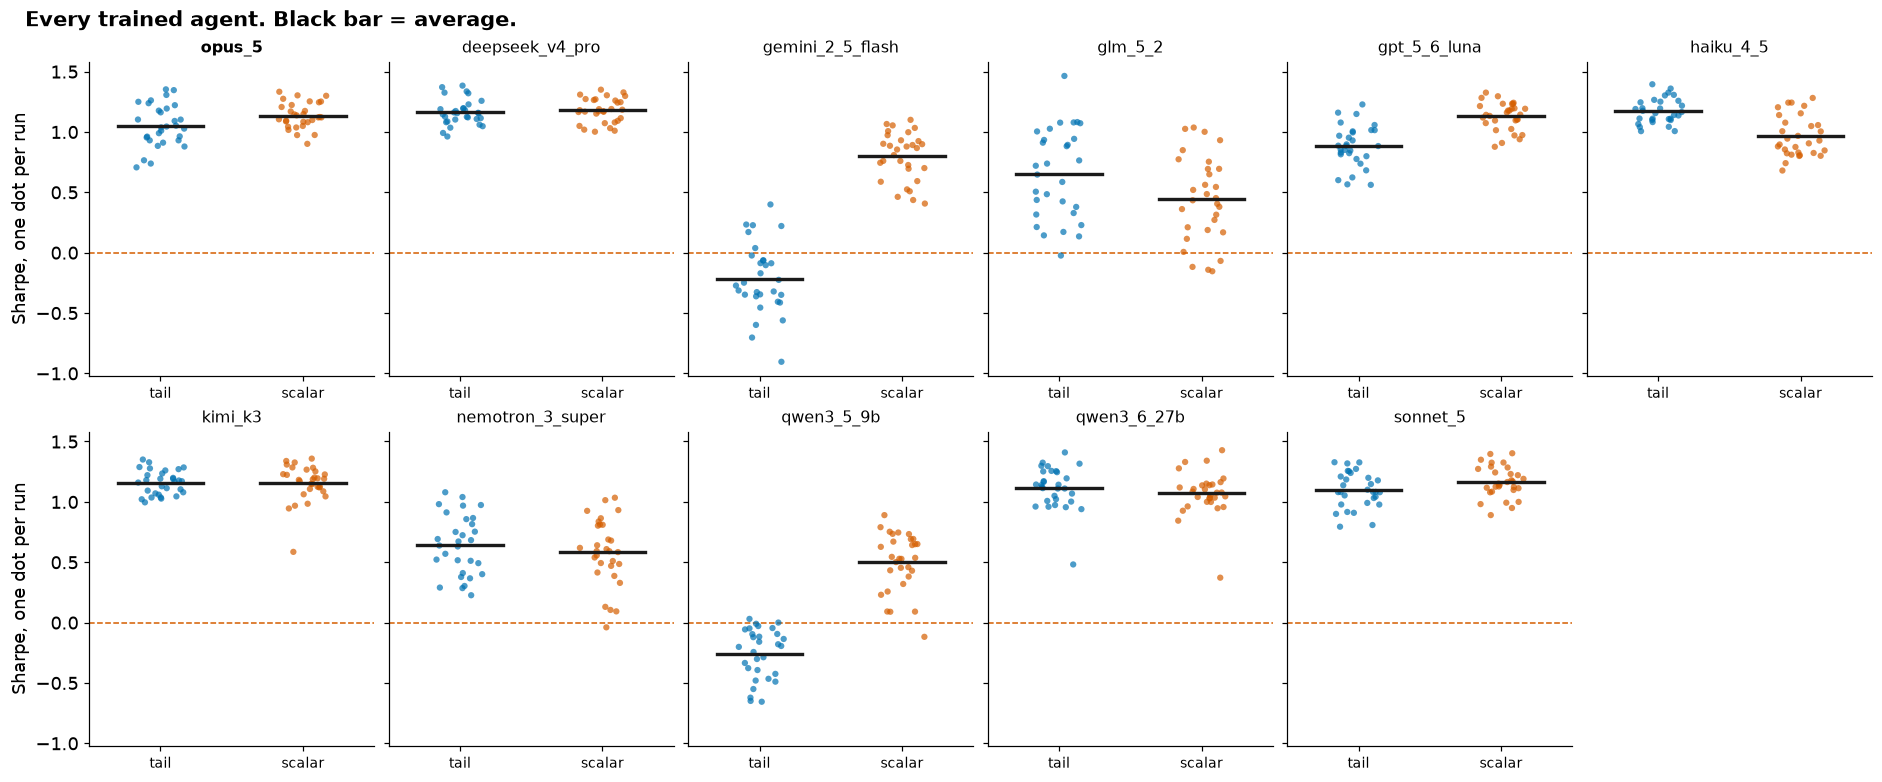

In [9]:
fig, axes = plt.subplots(2, 6, figsize=(17.0, 7.0), sharey=True)
rng = np.random.default_rng(7)
for ax, l in zip(axes.ravel(), LINES):
    for k, a in enumerate(["distributional","scalar"]):
        v = cell(l, a).to_numpy()
        ax.scatter(k + rng.uniform(-0.17, 0.17, v.size), v, s=17,
                   color=[BLUE, RED][k], alpha=0.7, edgecolor="none", zorder=3)
        ax.plot([k-0.3, k+0.3], [v.mean()]*2, color="0.1", lw=2.2, zorder=4)
    ax.axhline(0, color=RED, lw=1.0, ls="--")
    ax.set_xticks([0,1]); ax.set_xticklabels(["tail","scalar"], fontsize=9)
    ax.set_xlim(-0.5, 1.5)
    ax.set_title(nm(l), fontsize=10.5,
                 fontweight="bold" if nm(l)==CONF else "normal")
for ax in axes.ravel()[len(LINES):]: ax.set_visible(False)
axes[0,0].set_ylabel("Sharpe, one dot per run"); axes[1,0].set_ylabel("Sharpe, one dot per run")
fig.suptitle("Every trained agent. Black bar = average.", x=0.01, ha="left",
             fontsize=13.5, fontweight="bold")
savefig(fig, FIG / "P9_runs.png"); plt.show()

- **The clouds overlap heavily on most models.** The average difference is a small signal inside a
  large spread. **That is why every comparison is paired.**
- Where they separate cleanly (`gemini_2_5_flash`, `qwen3_5_9b`, `haiku_4_5`), 30 runs is plenty.
- Where they overlap almost entirely (`deepseek_v4_pro`, `kimi_k3`), 30 runs cannot settle anything.

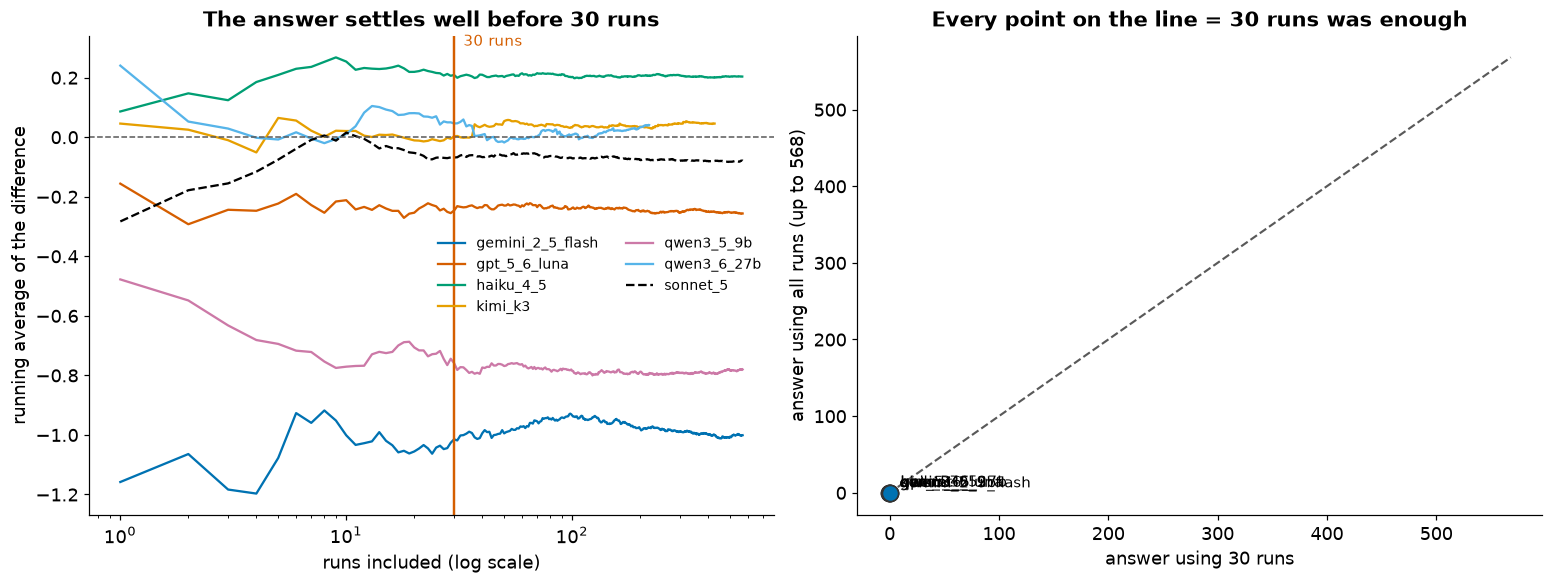

,runs,answer at 30,answer at full depth,same sign
model,,,,
gemini_2_5_flash,568,-1.0150,-1.0012,True
gpt_5_6_luna,568,-0.2467,-0.2565,True
haiku_4_5,566,0.2088,0.2034,True
kimi_k3,427,0.0028,0.0456,True
qwen3_5_9b,568,-0.7587,-0.7803,True
qwen3_6_27b,219,0.0458,0.0405,True
sonnet_5,568,-0.0685,-0.0793,True


models whose 30-run answer keeps its sign at full depth: 7 of 7


In [10]:
DEEP = [l for l in LINES if min(len(cell(l,"distributional")), len(cell(l,"scalar"))) >= 5
        and min(len(D[(D.line==l)&(D.arm=="distributional")]),
                len(D[(D.line==l)&(D.arm=="scalar")])) >= 200]
STY = [(OKABE_ITO["blue"],"-"),(OKABE_ITO["vermillion"],"-"),(OKABE_ITO["green"],"-"),
       (OKABE_ITO["orange"],"-"),(OKABE_ITO["purple"],"-"),(OKABE_ITO["skyblue"],"-"),
       (OKABE_ITO["black"],"--"),(OKABE_ITO["grey"],"--")]
fig, axes = plt.subplots(1, 2, figsize=(14.0, 5.2))

ax = axes[0]
val = []
for k, l in enumerate(DEEP):
    x = D[(D.line==l)&(D.arm=="distributional")].set_index("seed").sharpe.sort_index()
    y = D[(D.line==l)&(D.arm=="scalar")].set_index("seed").sharpe.sort_index()
    c = x.index.intersection(y.index)
    d = (x.loc[c]-y.loc[c]).to_numpy()
    run = np.cumsum(d)/np.arange(1, d.size+1)
    col, st = STY[k % len(STY)]
    ax.plot(np.arange(1, d.size+1), run, lw=1.5, color=col, ls=st, label=nm(l))
    val.append({"model": nm(l), "runs": d.size, "answer at 30": d[:30].mean(),
                "answer at full depth": d.mean(),
                "same sign": np.sign(d[:30].mean()) == np.sign(d.mean())})
ax.axhline(0, color="0.35", lw=1.0, ls="--")
ax.axvline(30, color=RED, lw=1.6); ax.text(33, ax.get_ylim()[1]*0.9, "30 runs", color=RED, fontsize=10)
ax.set_xscale("log"); ax.set_xlabel("runs included (log scale)")
ax.set_ylabel("running average of the difference")
ax.set_title("The answer settles well before 30 runs", fontweight="bold")
ax.legend(fontsize=9, ncols=2)

ax = axes[1]
V = pd.DataFrame(val)
ax.scatter(V["answer at 30"], V["answer at full depth"], s=110, color=BLUE, edgecolor="0.2", zorder=3)
lim = [min(V.min(numeric_only=True))-0.1, max(V.max(numeric_only=True))+0.1]
ax.plot(lim, lim, color="0.35", ls="--", lw=1.4)
for _, r in V.iterrows():
    ax.annotate(r["model"], (r["answer at 30"], r["answer at full depth"]), fontsize=9.5,
                xytext=(7,4), textcoords="offset points")
ax.set_xlabel("answer using 30 runs"); ax.set_ylabel("answer using all runs (up to 568)")
ax.set_title("Every point on the line = 30 runs was enough", fontweight="bold")
savefig(fig, FIG / "P10_depth_check.png"); plt.show()
display(V.set_index("model").round(4))
print("models whose 30-run answer keeps its sign at full depth: %d of %d" % (V["same sign"].sum(), len(V)))

### ★ The 30-run answer holds up

Seven models have run 200 to 568 times. **Every one of them keeps the same sign at full depth**, and
the largest drift is 0.043 Sharpe units.

> **This validates the whole reporting rung.** The numbers in this notebook are early, not
> provisional. What more runs buy is a **tighter interval**, not a different answer.

The right panel is the check in one picture: every model sits on the diagonal.

D:\tmp\ipykernel_21004\3939921570.py:44: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  bp = ax.boxplot(data, vert=True, patch_artist=True, widths=0.6,


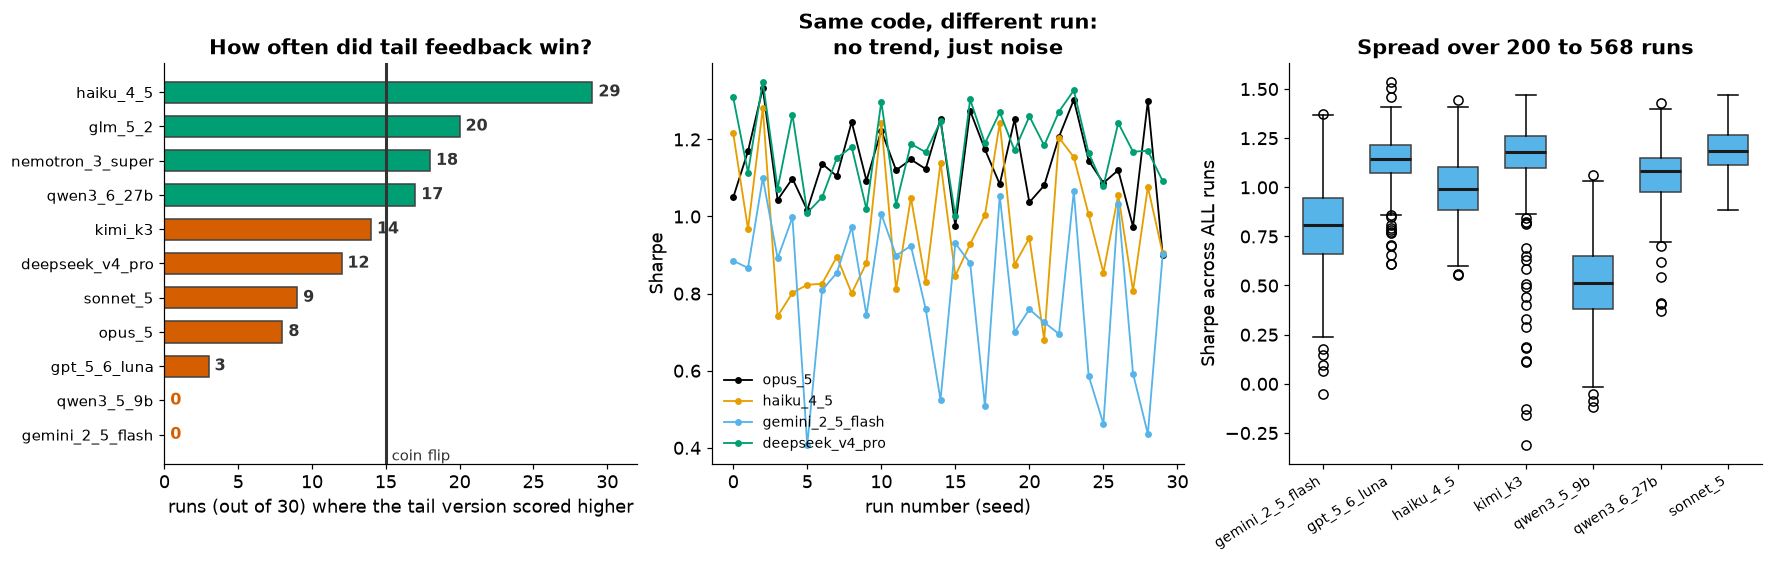

,won,of,mean gap,best run,worst run
model,,,,,
gemini_2_5_flash,0,30,-1.015,-0.174,-1.473
qwen3_5_9b,0,30,-0.759,-0.148,-1.441
gpt_5_6_luna,3,30,-0.247,0.086,-0.672
opus_5,8,30,-0.083,0.223,-0.431
sonnet_5,9,30,-0.069,0.257,-0.323
deepseek_v4_pro,12,30,-0.015,0.222,-0.134
kimi_k3,14,30,0.003,0.528,-0.182
qwen3_6_27b,17,30,0.046,0.584,-0.655
nemotron_3_super,18,30,0.060,0.764,-0.745


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16.0, 5.0))

# --- 1. how many of the 30 runs did the tail version actually win? ------------------
wins = []
for l in LINES:
    a, b = cell(l, "distributional"), cell(l, "scalar")
    k = a.index.intersection(b.index)
    d = (a.loc[k] - b.loc[k])
    wins.append({"model": nm(l), "won": int((d > 0).sum()), "of": len(d),
                 "mean gap": d.mean(), "best run": d.max(), "worst run": d.min()})
W = pd.DataFrame(wins).sort_values("won")
ax = axes[0]
y = np.arange(len(W))
ax.barh(y, W["won"], color=[GREEN if v > 15 else RED if v < 15 else GREY for v in W["won"]],
        edgecolor="0.25", height=0.62)
# label every bar, because a zero-win model draws NO bar and would otherwise read
# as missing data rather than as the strongest result on the panel
for i, v in enumerate(W["won"]):
    ax.text(v + 0.4, i, str(v), va="center", fontsize=10.5, fontweight="bold",
            color=RED if v == 0 else "0.2")
ax.axvline(15, color="0.2", lw=2.0)
ax.text(15.4, -0.75, "coin flip", fontsize=10, color="0.2")
ax.set_xlim(0, 32)
ax.set_yticks(y); ax.set_yticklabels(W.model, fontsize=10)
ax.set_xlabel("runs (out of 30) where the tail version scored higher")
ax.set_title("How often did tail feedback win?", fontweight="bold")

# --- 2. Sharpe against run number: is there a trend, or is it just noise? -----------
ax = axes[1]
SHOW = ["opus_5", "haiku_4_5", "gemini_2_5_flash", "deepseek_v4_pro"]
for k, m in enumerate(SHOW):
    l = "test" if m == "opus_5" else "test_leg_" + m
    v = cell(l, "scalar")
    ax.plot(v.index, v.values, lw=1.2, marker="o", ms=3.5,
            color=list(OKABE_ITO.values())[k], label=m)
ax.set_xlabel("run number (seed)"); ax.set_ylabel("Sharpe")
ax.set_title("Same code, different run:" + chr(10) + "no trend, just noise", fontweight="bold")
ax.legend(fontsize=9)

# --- 3. the full spread once a model has run hundreds of times ----------------------
ax = axes[2]
deep = [l for l in LINES if len(D[(D.line == l) & (D.arm == "scalar")]) >= 200]
data = [D[(D.line == l) & (D.arm == "scalar")].sharpe.dropna().values for l in deep]
bp = ax.boxplot(data, vert=True, patch_artist=True, widths=0.6,
                medianprops=dict(color="0.1", lw=2))
for b_ in bp["boxes"]: b_.set(facecolor=OKABE_ITO["skyblue"], edgecolor="0.25")
ax.set_xticklabels([nm(l) for l in deep], rotation=32, ha="right", fontsize=9)
ax.set_ylabel("Sharpe across ALL runs")
ax.set_title("Spread over 200 to 568 runs", fontweight="bold")
savefig(fig, FIG / "P13_seed_variation.png"); plt.show()
display(W.set_index("model").round(3))

### ★ Win rate says it more plainly than any p-value

The left panel counts, out of 30 runs, how often the tail-fed version simply scored higher.

- `gemini_2_5_flash` and `qwen3_5_9b`: **0 out of 30.** Not once.
- `haiku_4_5`: **29 out of 30.**
- `deepseek_v4_pro` and `kimi_k3`: about **half**, which is what no effect looks like.
- `opus_5`, the registered line: **8 of 30** on Sharpe, consistent with its small negative effect.

> **"It lost on all thirty runs" needs no statistics to be convincing.** Where the win rate is near
> 15, the arms are interchangeable on that model, whatever the average says.

### The middle panel: run number means nothing

Sharpe plotted against run number is flat noise. **There is no trend, no warm-up, no drift.** Run 3
is not better than run 27. That is what you want to see, and it confirms the runs are exchangeable,
which is the assumption every interval in this notebook rests on.

### The right panel: the spread does not vanish

Even after hundreds of runs the box stays wide. `sonnet_5` spans roughly **0.89 to 1.47** across 568
runs of identical code.

> **More runs do not make an individual run more predictable. They make the AVERAGE more precise.**
> That distinction is the entire reason for the seed ladder, and it is worth saying out loud, because
> it is the thing people most often get wrong about repeated experiments.

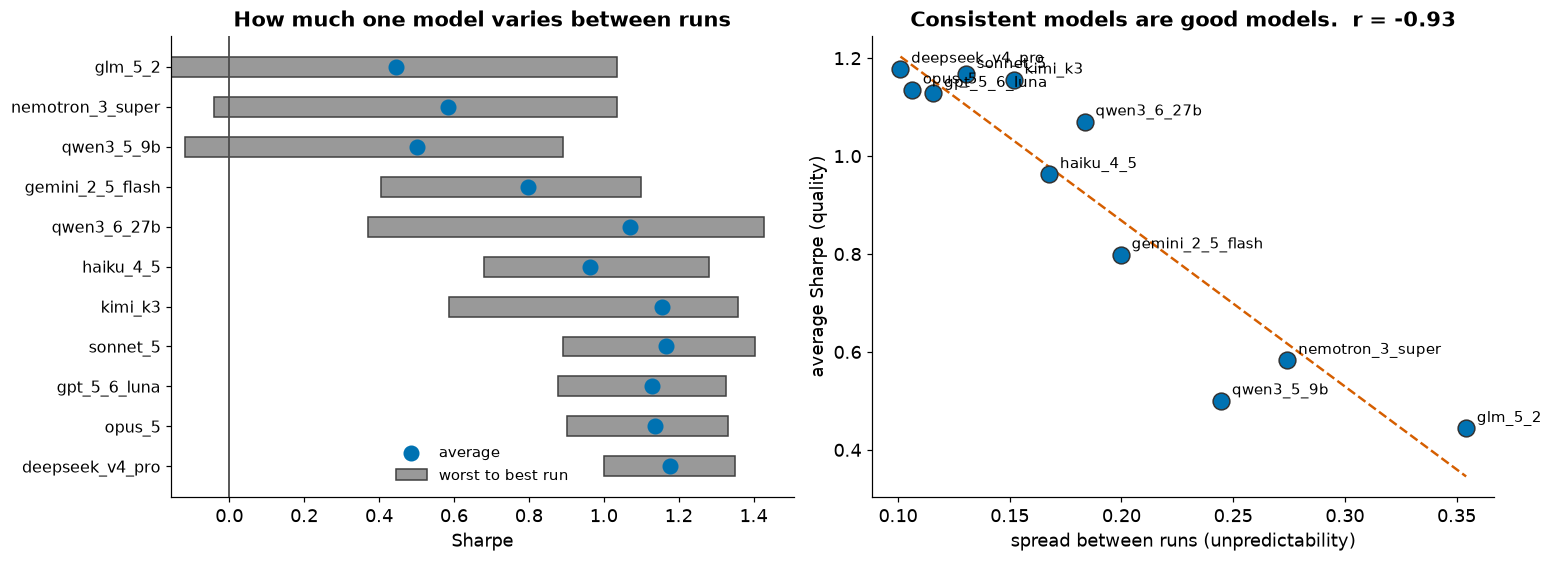

,spread across runs,best run,worst run,average,range
model,,,,,
deepseek_v4_pro,0.101,1.350,1.001,1.178,0.348
opus_5,0.106,1.333,0.901,1.135,0.432
gpt_5_6_luna,0.116,1.325,0.877,1.129,0.449
sonnet_5,0.130,1.403,0.890,1.167,0.512
kimi_k3,0.152,1.358,0.585,1.156,0.773
haiku_4_5,0.168,1.281,0.680,0.963,0.601
qwen3_6_27b,0.184,1.428,0.372,1.070,1.056
gemini_2_5_flash,0.200,1.100,0.406,0.799,0.694
qwen3_5_9b,0.245,0.890,-0.118,0.501,1.008


correlation between run-to-run spread and average quality: -0.933


In [12]:
st = []
for l in LINES:
    sc, di = cell(l,"scalar"), cell(l,"distributional")
    st.append({"model": nm(l), "spread across runs": sc.std(ddof=1),
               "best run": sc.max(), "worst run": sc.min(),
               "average": sc.mean(), "range": sc.max()-sc.min()})
S = pd.DataFrame(st).sort_values("spread across runs")
r = S[["spread across runs","average"]].corr().iloc[0,1]

fig, axes = plt.subplots(1, 2, figsize=(14.0, 5.0))
ax = axes[0]
y = np.arange(len(S))
# span worst->best, not 0->range. Anchoring at zero implied the worst run scored 0.
ax.barh(y, S["range"], left=S["worst run"], color=GREY, edgecolor="0.25", height=0.5,
        label="worst to best run")
ax.axvline(0, color="0.3", lw=1.2)
ax.scatter(S["average"], y, s=90, color=BLUE, zorder=4, label="average")
ax.set_yticks(y); ax.set_yticklabels(S.model, fontsize=10.5)
ax.set_xlabel("Sharpe"); ax.legend(fontsize=10)
ax.set_title("How much one model varies between runs", fontweight="bold")

ax = axes[1]
ax.scatter(S["spread across runs"], S["average"], s=120, color=BLUE, edgecolor="0.2", zorder=3)
for _, row in S.iterrows():
    ax.annotate(row["model"], (row["spread across runs"], row["average"]), fontsize=9.5,
                xytext=(7,4), textcoords="offset points")
z = np.polyfit(S["spread across runs"], S["average"], 1)
xs = np.linspace(S["spread across runs"].min(), S["spread across runs"].max(), 20)
ax.plot(xs, np.polyval(z, xs), color=RED, ls="--", lw=1.6)
ax.set_xlabel("spread between runs (unpredictability)")
ax.set_ylabel("average Sharpe (quality)")
ax.set_title("Consistent models are good models.  r = %+0.2f" % r, fontweight="bold")
savefig(fig, FIG / "P11_stability.png"); plt.show()
display(S.set_index("model").round(3))
print("correlation between run-to-run spread and average quality: %+0.3f" % r)

### ★ Consistency and quality are almost the same thing

**r = −0.93.** The models that give the same answer every time are the models that give the best
answer.

- `deepseek_v4_pro`, `opus_5`, `sonnet_5`: tight spread, high Sharpe.
- `glm_5_2`, `nemotron_3_super`, `qwen3_5_9b`: wide spread, low Sharpe.

**Why this is more than a curiosity.** A weak model does not simply write a worse reward. It writes
an *unreliable* one, so the same code trained twice lands in different places. **Reward quality and
reward reliability are the same axis.**

**Practical consequence:** run-to-run spread is measurable after a handful of runs, long before you
know whether the reward is any good. **It is an early warning signal that costs almost nothing.**

## 8. Why the models differ: they trade differently

Tail feedback changes **how much the agent trades**. Trading is expensive.

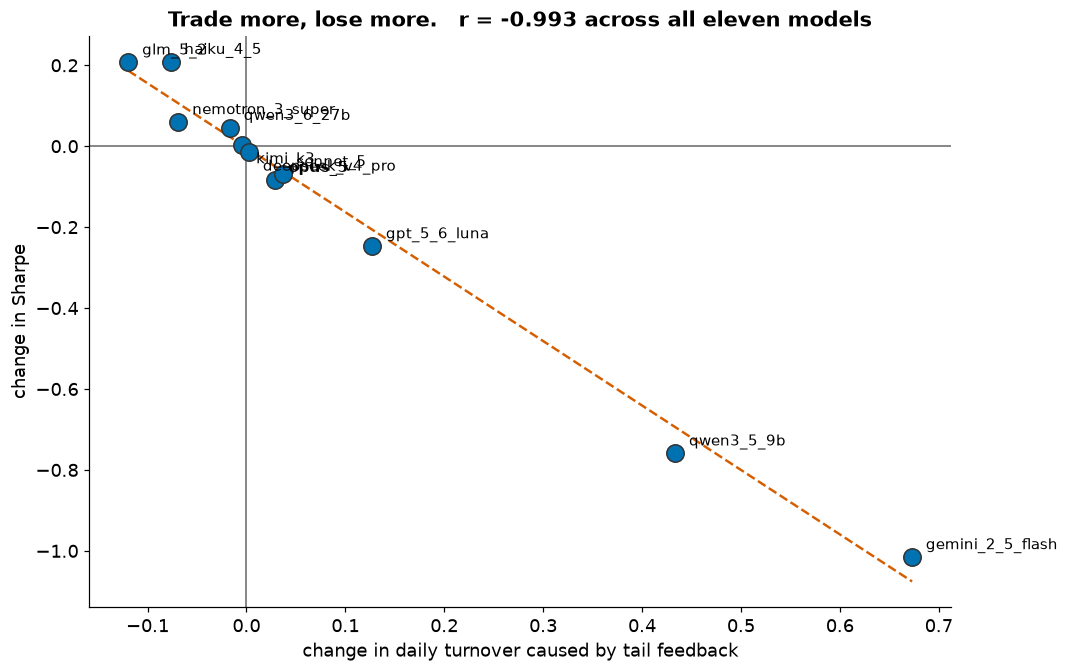

,turn_scalar,turn_distributional,turnover change,gross change,net change
model,,,,,
glm_5_2,0.405,0.286,-0.119,0.014,0.207
haiku_4_5,0.084,0.008,-0.077,0.053,0.209
nemotron_3_super,0.372,0.303,-0.069,-0.001,0.060
qwen3_6_27b,0.049,0.033,-0.017,0.012,0.046
kimi_k3,0.013,0.009,-0.004,-0.005,0.003
deepseek_v4_pro,0.008,0.010,0.003,-0.011,-0.015
opus_5,0.028,0.057,0.029,-0.013,-0.083
sonnet_5,0.011,0.047,0.037,-0.001,-0.069
gpt_5_6_luna,0.014,0.141,0.127,-0.012,-0.247


turnover change vs NET Sharpe change   : r = -0.993
turnover change vs GROSS Sharpe change : r = -0.975


In [13]:
g = (D[D.floor & D.arm.isin(["distributional", "scalar"]) & D.model.isin(MODELS)]
     .groupby(["model", "arm"]).agg(net=("sharpe", "mean"), gross=("sharpe_gross", "mean"),
                                    turn=("turnover_mean", "mean")).unstack())
g.columns = ["_".join(c) for c in g.columns]
g["turnover change"] = g.turn_distributional - g.turn_scalar
g["net change"] = g.net_distributional - g.net_scalar
g["gross change"] = g.gross_distributional - g.gross_scalar
g = g.sort_values("turnover change")
r = g[["turnover change", "net change"]].corr().iloc[0, 1]

fig, ax = plt.subplots(figsize=(9.6, 6.0))
ax.scatter(g["turnover change"], g["net change"], s=130, color=BLUE, edgecolor="0.2", zorder=3)
for m_, row in g.iterrows():
    off = (9, 5) if abs(row["net change"]) > 0.04 else (9, -12)
    ax.annotate(m_, (row["turnover change"], row["net change"]), fontsize=10,
                xytext=off, textcoords="offset points",
                fontweight="bold" if m_ == CONF else "normal")
z = np.polyfit(g["turnover change"], g["net change"], 1)
xs = np.linspace(g["turnover change"].min(), g["turnover change"].max(), 20)
ax.plot(xs, np.polyval(z, xs), color=RED, lw=1.6, ls="--", zorder=2)
ax.axhline(0, color="0.4", lw=1); ax.axvline(0, color="0.4", lw=1)
ax.set_xlabel("change in daily turnover caused by tail feedback")
ax.set_ylabel("change in Sharpe")
ax.set_title("Trade more, lose more.   r = %+0.3f across all eleven models" % r, fontweight="bold")
savefig(fig, FIG / "P2_turnover.png"); plt.show()
display(g[["turn_scalar", "turn_distributional", "turnover change", "gross change", "net change"]].round(3))
print("turnover change vs NET Sharpe change   : r = %+0.3f" % r)
print("turnover change vs GROSS Sharpe change : r = %+0.3f"
      % g[["turnover change", "gross change"]].corr().iloc[0, 1])

**This one variable explains almost the whole picture.**

- **r = −0.993.** Knowing only whether tail feedback made a model trade more or less nearly tells you
  whether it gained or lost.
- **Gross Sharpe barely moves.** The strategies pick similarly good positions. **The damage is
  entirely trading cost.**
- The two collapses, `gemini_2_5_flash` (0.22 → 0.89 turnover) and `qwen3_5_9b` (0.40 → 0.83), stay
  profitable *before* costs and go negative after.
- `opus_5` moved only 0.028 → 0.057. **Small cost, real tail gain.** That is why it is the one model
  that passes.

⚠ Correlation across eleven points, not a manipulation. Repricing the grid at other cost levels needs
no retraining and would settle it. Not yet run.

## 9. What actually drives the outcome

Three things could matter: which model, which feedback, or luck.

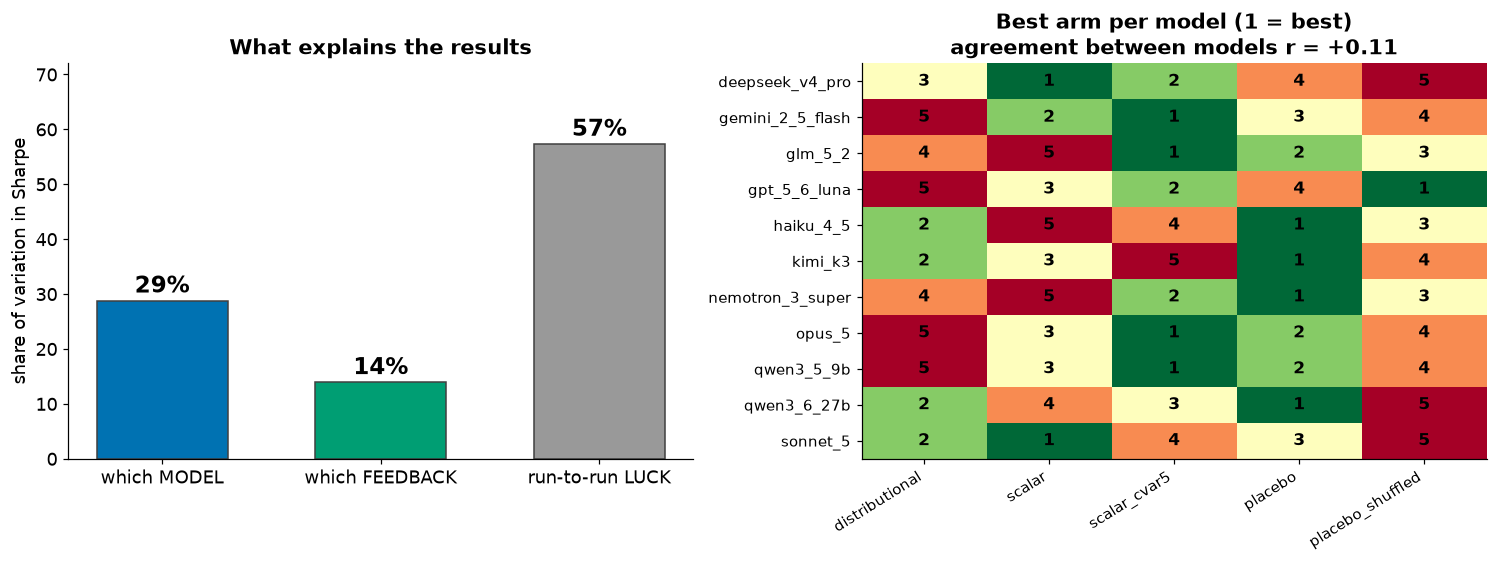

model 28.8% | feedback arm 13.9% | seed and interactions 57.3%


In [14]:
A = D[D.floor & D.model.isin(MODELS)
      & D.arm.isin(["distributional","scalar","scalar_cvar5","placebo","placebo_shuffled"])]
tot = A.sharpe.var()
gm, ga = A.groupby("model").sharpe.mean(), A.groupby("arm").sharpe.mean()
v_m, v_a = A.model.map(gm).var(), A.arm.map(ga).var()
v_r = (A.sharpe - A.model.map(gm) - A.arm.map(ga) + A.sharpe.mean()).var()

fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.0))
ax = axes[0]
parts = [("which MODEL", 100*v_m/tot, BLUE), ("which FEEDBACK", 100*v_a/tot, GREEN),
         ("run-to-run LUCK", 100*v_r/tot, GREY)]
ax.bar([p[0] for p in parts], [p[1] for p in parts], color=[p[2] for p in parts],
       edgecolor="0.25", width=0.6)
for i, p in enumerate(parts):
    ax.text(i, p[1]+1.5, "%.0f%%" % p[1], ha="center", fontsize=15, fontweight="bold")
ax.set_ylabel("share of variation in Sharpe"); ax.set_ylim(0, 72)
ax.set_title("What explains the results", fontweight="bold")

ax = axes[1]
piv = A.groupby(["model","arm"]).sharpe.mean().unstack()[
      ["distributional","scalar","scalar_cvar5","placebo","placebo_shuffled"]]
rk = piv.rank(axis=1, ascending=False)
im = ax.imshow(rk.values, cmap="RdYlGn_r", vmin=1, vmax=5, aspect="auto")
ax.set_xticks(range(5)); ax.set_xticklabels(piv.columns, rotation=32, ha="right", fontsize=10)
ax.set_yticks(range(len(rk))); ax.set_yticklabels(rk.index, fontsize=10)
for i in range(rk.shape[0]):
    for j in range(rk.shape[1]):
        ax.text(j, i, int(rk.values[i,j]), ha="center", va="center", fontsize=11, fontweight="bold")
from itertools import combinations
cors = [np.corrcoef(rk.loc[a], rk.loc[b])[0,1] for a,b in combinations(rk.index,2)]
ax.set_title("Best arm per model (1 = best)\nagreement between models r = %+0.2f" % np.mean(cors),
             fontweight="bold")
ax.grid(False)
savefig(fig, FIG / "P3_what_drives.png"); plt.show()
print("model %.1f%% | feedback arm %.1f%% | seed and interactions %.1f%%"
      % (100*v_m/tot, 100*v_a/tot, 100*v_r/tot))

- **Which model you use matters about twice as much as what you show it** (29% against 14%).
- **Run-to-run luck dwarfs both** (57%). This is the argument for 30 seeds per arm, and against any
  paper reporting a handful of runs.
- **The models do not agree on which feedback is best** (agreement r = +0.11). `distributional` ranks
  near the top for `haiku_4_5`, `kimi_k3`, `qwen3_6_27b`, and last for four others.

> **There is no universally best feedback design. It depends on the model.** Most papers in this area
> demonstrate a technique on one model and present it as a property of the technique.

## 10. The failure mechanism: some models wrote code that crashes

Reward code runs inside the training loop. When it raises, a default is substituted and counted.

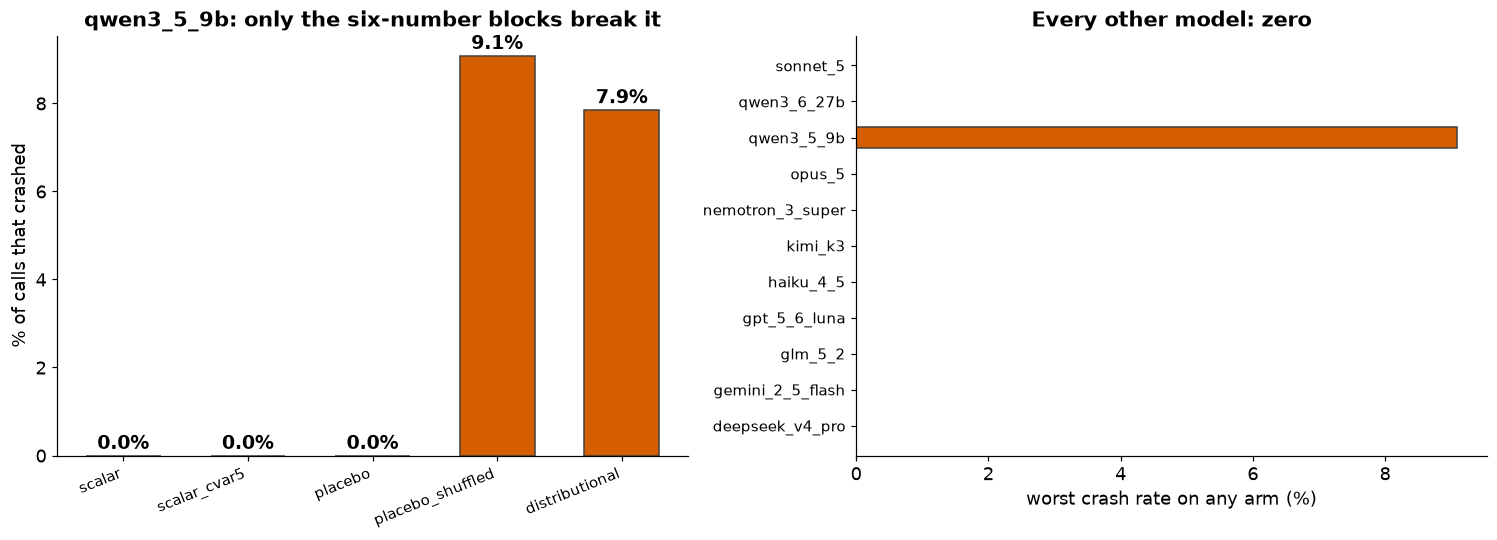

cells with any crash: 4 of 70
   qwen3_5_9b           placebo_shuffled       9.08%
   qwen3_5_9b           distributional         7.85%
   opus_5               baseline_differential_downside_ratio   0.00%
   opus_5               baseline_differential_sharpe   0.00%


In [15]:
byc = D[D.floor & D.model.isin(MODELS)].groupby(["model","arm"]).safe_default_rate.mean()
nz = byc[byc > 1e-9].sort_values(ascending=False)
worst = nz.index[0][0]
arms = ["scalar","scalar_cvar5","placebo","placebo_shuffled","distributional"]

fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.8))
ax = axes[0]
vals = [100*byc.get((worst,a),0.0) for a in arms]
b = ax.bar(np.arange(len(arms)), vals, color=[GREY,GREY,GREY,RED,RED], edgecolor="0.25", width=0.6)
for bb,v in zip(b, vals): ax.text(bb.get_x()+bb.get_width()/2, v+0.15, "%.1f%%" % v,
                                  ha="center", fontsize=12.5, fontweight="bold")
ax.set_xticks(np.arange(len(arms))); ax.set_xticklabels(arms, rotation=22, ha="right", fontsize=10)
ax.set_ylabel("% of calls that crashed")
ax.set_title("%s: only the six-number blocks break it" % worst, fontweight="bold")

ax = axes[1]
allm = byc.groupby("model").max().reindex(sorted(MODELS)) * 100
ax.barh(np.arange(len(allm)), allm.values, color=[RED if v>0.01 else GREY for v in allm.values],
        edgecolor="0.25", height=0.6)
ax.set_yticks(np.arange(len(allm))); ax.set_yticklabels(allm.index, fontsize=10)
ax.set_xlabel("worst crash rate on any arm (%)")
ax.set_title("Every other model: zero", fontweight="bold")
savefig(fig, FIG / "P4_crashes.png"); plt.show()
print("cells with any crash: %d of %d" % (len(nz), byc.size))
for (m,a),v in nz.head(4).items(): print("   %-20s %-20s %6.2f%%" % (m, a, 100*v))

- **`qwen3_5_9b` is the only model whose code fails.** Shown one number: 0%. Shown the six-number
  block: **7.9%**. Scrambled block: 9.1%.
- Those are exactly its two failing arms. It trained against a reward that was silently defaulting
  one call in thirteen.
- **Every other model: zero.** So this is a capability limit, not a flaw in the feedback design.

⚠ **It does not explain `gemini_2_5_flash`**, which never crashes and still collapses. That one is
explained by turnover (Section 8). **Two failures, one shared mechanism, one with an extra problem.**

## 11. Model size: two families, two different stories

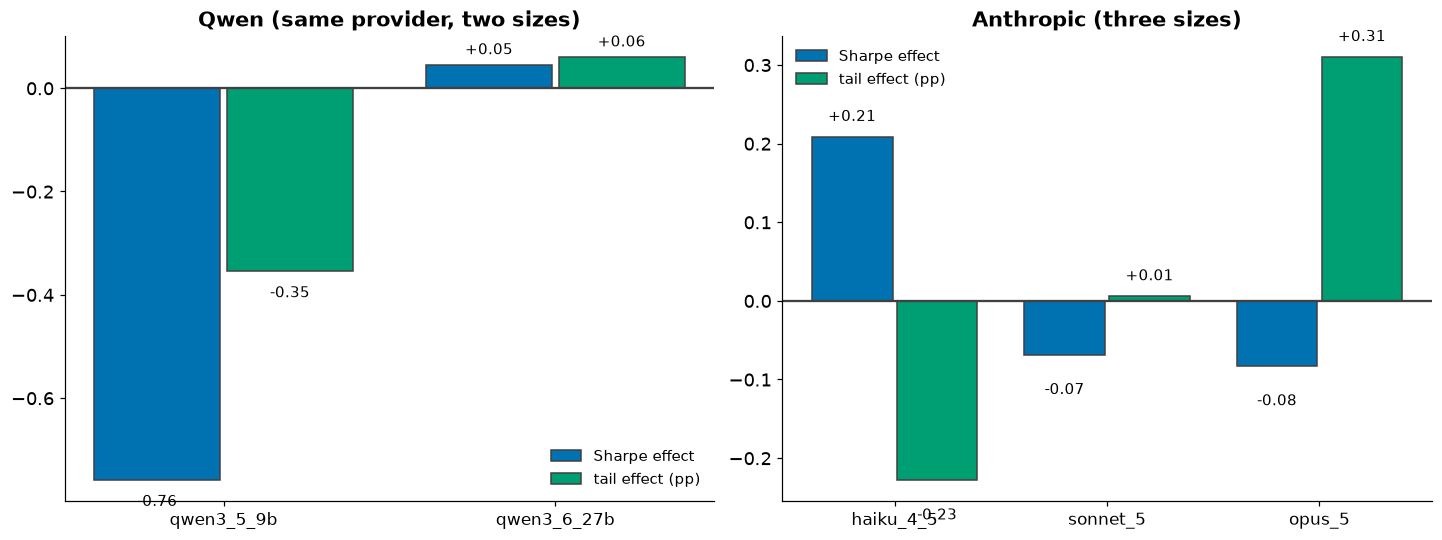

In [16]:
fams = {"Qwen (same provider, two sizes)": ["qwen3_5_9b","qwen3_6_27b"],
        "Anthropic (three sizes)": ["haiku_4_5","sonnet_5","opus_5"]}
fig, axes = plt.subplots(1, 2, figsize=(13.0, 4.8))
for ax,(fam,ms) in zip(axes, fams.items()):
    ms = [m for m in ms if m in piv.index]
    sh = [piv.loc[m,"distributional"]-piv.loc[m,"scalar"] for m in ms]
    cv = [paired("test" if m=="opus_5" else "test_leg_"+m,"distributional","scalar","oos_cvar_05").mean()*100
          for m in ms]
    x = np.arange(len(ms))
    ax.bar(x-0.2, sh, width=0.38, color=BLUE, edgecolor="0.25", label="Sharpe effect")
    ax.bar(x+0.2, cv, width=0.38, color=GREEN, edgecolor="0.25", label="tail effect (pp)")
    ax.axhline(0, color="0.25", lw=1.5)
    ax.set_xticks(x); ax.set_xticklabels(ms, fontsize=11)
    ax.set_title(fam, fontweight="bold"); ax.legend(fontsize=10)
    for i,(a_,b_) in enumerate(zip(sh,cv)):
        ax.text(i-0.2, a_+(0.02 if a_>=0 else -0.05), "%+.2f" % a_, ha="center", fontsize=10)
        ax.text(i+0.2, b_+(0.02 if b_>=0 else -0.05), "%+.2f" % b_, ha="center", fontsize=10)
savefig(fig, FIG / "P5_size.png"); plt.show()

- **Qwen is clean.** Same provider, same setup, different size. The 9B is badly harmed. The 27B is not.
- ⚠ **Anthropic is not.** The *smallest*, `haiku_4_5`, has the **best Sharpe effect** (+0.21). A simple
  "bigger is better" story is refuted by our own data.
- **The resolution:** on the **tail**, `haiku_4_5` gets *worse* (−0.23pp) while `opus_5` gets *better*
  (+0.31pp). Haiku gained Sharpe by trading less, not by managing risk.

> **Capability predicts whether a model can use tail information to improve the tail. It does not
> predict Sharpe, because Sharpe is dominated by turnover.**

Raise this yourself. If an examiner spots the non-monotonic ladder first, the capability story looks
invented after the fact.

## 12. H1: against eleven human-written objectives

Objectives taken from published finance papers, implemented as specified.

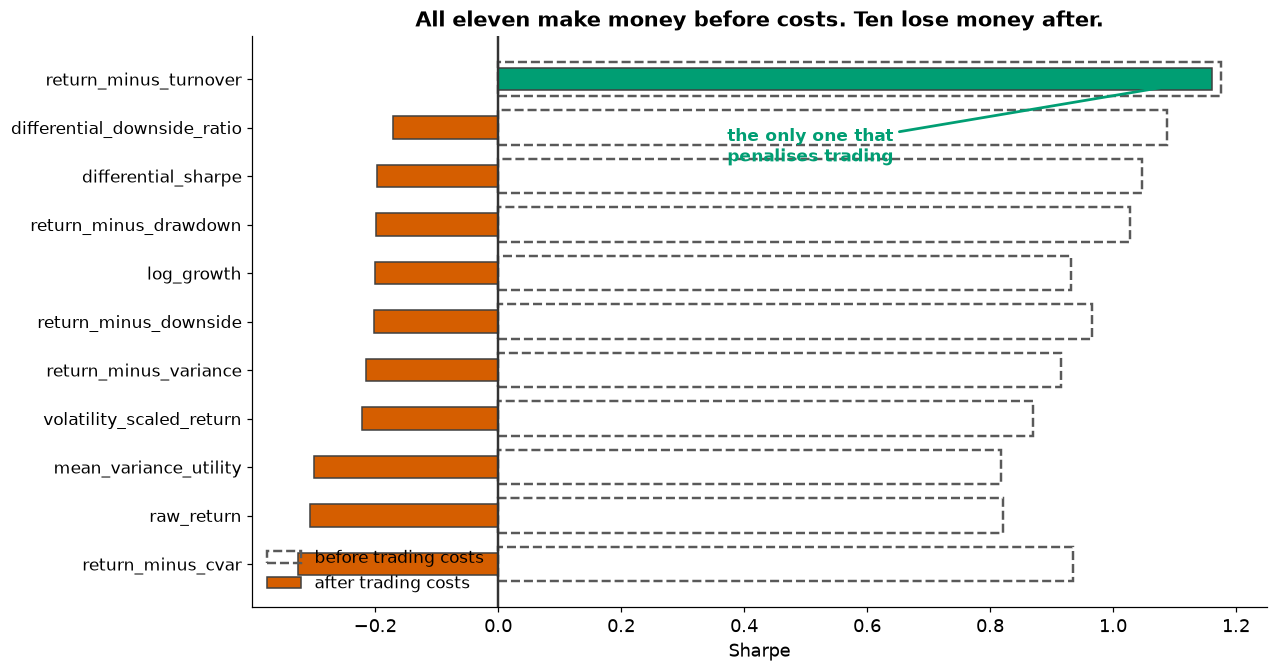

turnover: survivor 0.0077/day, median of the other ten 0.8885/day
every LLM arm scored between +1.05 and +1.16


In [17]:
o = D[(D.line=="test") & D.floor]
canon = o[o.arm.str.startswith("baseline_")].groupby("arm").agg(
    net=("sharpe","mean"), gross=("sharpe_gross","mean"), turn=("turnover_mean","mean")).sort_values("net")
canon.index = [i.replace("baseline_","") for i in canon.index]
fig, ax = plt.subplots(figsize=(11.5, 6.0))
y = np.arange(len(canon))
ax.barh(y, canon.gross, height=0.72, facecolor="none", edgecolor="0.35", lw=1.6, ls="--",
        label="before trading costs")
ax.barh(y, canon.net, height=0.46, color=[GREEN if v>0 else RED for v in canon.net],
        edgecolor="0.25", label="after trading costs")
ax.axvline(0, color="0.2", lw=1.6)
ax.set_yticks(y); ax.set_yticklabels(canon.index, fontsize=11)
ax.set_xlabel("Sharpe")
ax.set_title("All eleven make money before costs. Ten lose money after.", fontweight="bold")
ax.legend(loc="lower left", fontsize=11)
ax.annotate("the only one that\npenalises trading", xy=(canon.net.iloc[-1], len(canon)-1),
            xytext=(0.55,0.78), textcoords="axes fraction", fontsize=11, color=GREEN,
            fontweight="bold", ha="center", arrowprops=dict(arrowstyle="->", color=GREEN, lw=1.8))
savefig(fig, FIG / "P6_humans.png"); plt.show()
print("turnover: survivor %.4f/day, median of the other ten %.4f/day"
      % (canon.turn.min(), canon.turn.drop(canon.turn.idxmin()).median()))
llm = o[o.arm.isin(["distributional","scalar","scalar_cvar5","placebo","placebo_shuffled"])]
print("every LLM arm scored between %+0.2f and %+0.2f"
      % (llm.groupby("arm").sharpe.mean().min(), llm.groupby("arm").sharpe.mean().max()))

- **All eleven are profitable before costs. Ten lose money after.** They trade ~89% of the portfolio
  daily and give the whole gross return to fees.
- **The survivor is the only one with a turnover penalty**, trades 0.8% a day, and is the best arm in
  the study.
- Every automated designer found the cost constraint without being told.

> **The claim is not "AI beats humans". It is: ten of eleven published objectives do not price
> transaction costs, and every automated designer discovered it must.**

⚠ The baselines are un-tuned and evaluated once. The automated arms are winners of a 30-candidate
search. **Section 13 prices that.**

## 13. H4: against optimisers with no language model

Four search methods, identical 30-candidate budget, same reward space.

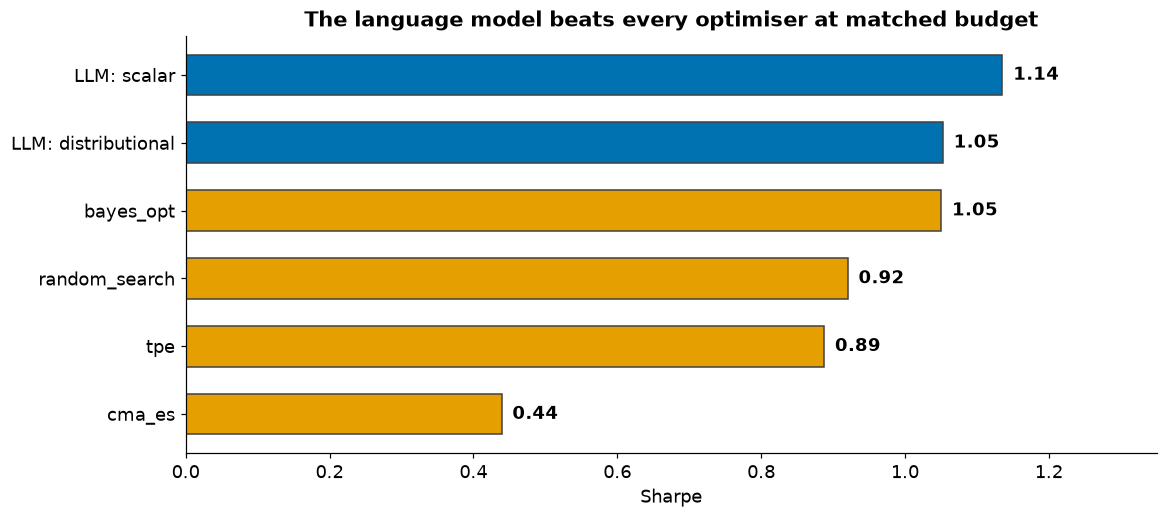

   scalar           vs random_search   +0.215  LLM better
   scalar           vs bayes_opt       +0.085  LLM better
   scalar           vs cma_es          +0.696  LLM better
   scalar           vs tpe             +0.248  LLM better
   distributional   vs random_search   +0.132  LLM better
   distributional   vs bayes_opt       +0.002  tie
   distributional   vs cma_es          +0.614  LLM better
   distributional   vs tpe             +0.165  LLM better


In [18]:
dfo = ["random_search","bayes_opt","cma_es","tpe"]
vals = {a: cell("test", a).mean() for a in dfo}
vals["LLM: scalar"] = cell("test","scalar").mean()
vals["LLM: distributional"] = cell("test","distributional").mean()
srt = sorted(vals.items(), key=lambda kv: kv[1])
fig, ax = plt.subplots(figsize=(10.5, 4.6))
ax.barh(np.arange(len(srt)), [v for _,v in srt],
        color=[BLUE if k.startswith("LLM") else ORANGE for k,_ in srt], edgecolor="0.25", height=0.6)
for i,(k,v) in enumerate(srt): ax.text(v+0.015, i, "%.2f" % v, va="center", fontsize=12, fontweight="bold")
ax.set_yticks(np.arange(len(srt))); ax.set_yticklabels([k for k,_ in srt], fontsize=11.5)
ax.set_xlabel("Sharpe"); ax.set_xlim(0, 1.35)
ax.set_title("The language model beats every optimiser at matched budget", fontweight="bold")
savefig(fig, FIG / "P7_optimisers.png"); plt.show()
for arm in ("scalar","distributional"):
    for comp in dfo:
        m, lo, hi = boot(paired("test", arm, comp, "sharpe"))
        print("   %-16s vs %-14s %+7.3f  %s" % (arm, comp, m,
              "LLM better" if lo>0 else ("LLM worse" if hi<0 else "tie")))

- **Both LLM arms beat all four optimisers.** They had the same budget on the same problem.
- **This answers the H1 objection.** The gap is not from having 30 attempts. It is from what the model
  does with them.
- ⚠ `distributional` only **ties** `bayes_opt`, because it deliberately gave up Sharpe. And `cma_es`
  is unusually weak. **`bayes_opt` is the real benchmark, not four easy wins.**

## 14. H3: does iterating help?

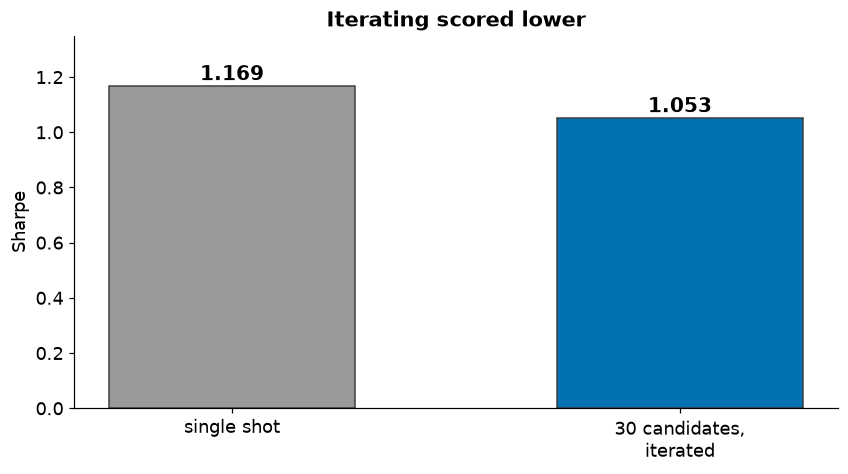

difference -0.116  [-0.164, -0.068], 30 paired runs


In [19]:
a, b = cell("test","distributional"), cell("test_h3_singleshot","distributional")
c = a.index.intersection(b.index)
m, lo, hi = boot((a.loc[c]-b.loc[c]).to_numpy(float))
fig, ax = plt.subplots(figsize=(7.6, 4.2))
bars = ax.bar(["single shot","30 candidates,\niterated"], [b.loc[c].mean(), a.loc[c].mean()],
              color=[GREY, BLUE], width=0.55, edgecolor="0.25")
for bb,v in zip(bars,[b.loc[c].mean(), a.loc[c].mean()]):
    ax.text(bb.get_x()+bb.get_width()/2, v+0.02, "%.3f" % v, ha="center", fontsize=13, fontweight="bold")
ax.set_ylabel("Sharpe"); ax.set_ylim(0,1.35)
ax.set_title("Iterating scored lower", fontweight="bold")
savefig(fig, FIG / "P8_iteration.png"); plt.show()
print("difference %+0.3f  [%+0.3f, %+0.3f], %d paired runs" % (m, lo, hi, len(c)))

- **The single shot scored higher**, by 0.116.
- **The likely reason:** the iterated arm is the tail-fed arm. More rounds of tail feedback means more
  of the safety-for-return trade. **Iteration worked. Sharpe is the wrong axis to see it on.**

⚠ **Confounded by design.** The single-shot unit also runs `distributional`, so this compares one
round of tail feedback against thirty, not iteration against no iteration. **Present as an open
question with a leading hypothesis**, not a settled result.

## 15. How much can we trust 30 runs?

In [20]:
dec = []
for l in LINES:
    d = paired(l, "distributional", "scalar", "sharpe")   # seed-matched, not position-matched
    if d.size < 5: continue
    dec.append({"model": nm(l), "spread between runs": d.std(ddof=1),
                "runs needed for a firm verdict": int(np.ceil((2*1.645*d.std(ddof=1)/0.05)**2))})
DEC = pd.DataFrame(dec).sort_values("spread between runs")
display(DEC.set_index("model").round(3))
print("Opus effect on Sharpe is -0.083 against a run-to-run spread of %.3f"
      % DEC.set_index("model").loc[CONF,"spread between runs"])

,spread between runs,runs needed for a firm verdict
model,,
deepseek_v4_pro,0.090,36
haiku_4_5,0.124,67
sonnet_5,0.137,82
kimi_k3,0.149,97
opus_5,0.161,112
gpt_5_6_luna,0.208,188
qwen3_6_27b,0.216,203
qwen3_5_9b,0.291,367
gemini_2_5_flash,0.340,502


Opus effect on Sharpe is -0.083 against a run-to-run spread of 0.161


- **Run-to-run spread is 0.09 to 0.58 Sharpe units.** Many of the effects here are smaller than that.
  **Hence pairing, and hence 30 runs minimum.**
- **Detecting a difference is easier than proving there is none.** Bounding Opus's Sharpe difference
  inside the registered margin needs **~112 runs**. We have 30.
- ⚠ **A pre-launch estimate did not reproduce.** The pilot predicted a spread of 0.369 and a
  *negative* pairing benefit. The campaign measures ~0.21 and a *positive* one. **The pilot was
  pessimistic on a small sample.**

## 16. Why the design carries the result

- **The prediction predates the data.** Three outcomes were registered and one predicted. That one
  occurred. The file is hash-sealed.
- **The test is hostile by design.** Beat all three comparators, and the score is the worst leg.
- **Stopping date fixed in advance** (27 August). Optional stopping is impossible.
- **Selection is tail-blind**, so a tail gain cannot be a selection artefact.
- **Eleven models**, five open-weight and hash-pinned.
- **Every comparison is paired run by run.**

> **The result does not depend on trusting the analyst.**

## 17. Limitations

1. **30 runs, rung 1 of 7.** Direction established, precision not.
2. **Cannot yet prove equivalence** on Sharpe. Needs ~112 runs.
3. **One market, one period** (UK and US equities, 2020 to mid-2026).
4. **Trading costs are fixed and linear.** H1 depends on that. Repricing needs no retraining, not run.
5. **The mechanism instruments have not been run.** SQ1 to SQ3 answered by outcome only.
6. **H3's explanation is a hypothesis**, and the comparison is confounded.
7. **One model of eleven passes H2-Tail.** The capability account rests on one clean size pair.
8. **`placebo` is not neutral on every model**, which complicates that control on those lines.
9. **The tail gain is modest** (~0.3pp) against a 3.6pp return cost. Roughly one-for-one.
10. **Two archive gaps:** per-record wall-clock is zero, training-return curve never captured.

## 18. Summary

> **Across eleven models, showing a reward designer the shape of the losses changes how much its agent
> trades, and that single channel explains almost the whole picture (r = −0.993). Where turnover rose,
> models lost money to fees. Where it fell, they gained. On the registered confirmatory model the
> change was small and bought a genuinely safer tail: worst-day losses 1.64% against 1.95%, drawdown
> 17.6% against 20.1%, for 3.6 percentage points of annual return.**

| | |
|---|---|
| turnover change vs Sharpe change | **r = −0.993** across 11 models |
| variance: model / feedback / luck | **29% / 14% / 57%** |
| agreement between models on best arm | **r = +0.11** |
| models passing H2-Tail on all 3 legs | **1 of 11** (`opus_5`, registered in advance) |
| human objectives profitable after costs | **1 of 11** (11 of 11 before) |
| `qwen3_5_9b` code failure rate | **7.9%** with tail block, **0%** with scalar |
| tail gain vs return cost | **3.9% vs 3.6% a year** |
| runs needed for a firm equivalence verdict | **~112**, we have 30 |

**Four questions you will get**

**"Lower Sharpe means it failed."** It traded return for tail safety. Both moves are significant.
Sharpe picks one weighting. We report the parts.

**"Just a longer prompt?"** A same-length empty block was run and beaten at p < 0.0001. So was a
single tail number.

**"Only one model passed."** That model was named in advance. The other ten show *why* it matters
which model you use, which is itself a finding.

**"Did you pick the test afterwards?"** No. Hypotheses, rules, metrics and stop date are in a
hash-sealed file predating the campaign.